In [1]:
#!pip install astropy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as maths
import scipy
import astropy.stats as astro



/its/home/nn268/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
antTrackDF = pd.read_csv("AbbottsWoodsCombinedTidy.csv")

antTrackDF['ID'] = antTrackDF.ID.astype(str)

/tmp/ipykernel_164016/2758679799.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  antTrackDF = pd.read_csv("AbbottsWoodsCombinedTidy.csv")


# speed

In [259]:
def stats_condition(df, nest, condition, all=True):
    # This function will loop though all IDs of a nest and or condition
    # it then calculates path speed, straightness, distance travelled (between rows i & i-1 and total), 
    # these metrics are then plotted in box plots
    
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    #print("unique IDs in nest/ condition combo:", type(unique_ids), unique_ids) 

    # create lists to store one time metrics for later plotting
    straight_list = []
    speed_list = []
    dist_list = []
    framesPerSec = 1/100#25  # video recorded in 25 frames/ second

    for id in unique_ids:
        # subset by ID - individual trial
        usedf = newdf[newdf['ID'] == id].copy()
        
        max_len=len(usedf)
        total_frames = usedf['frame'].iloc[-1]
        
        _x = np.array(usedf['x'])
        _y =  np.array(usedf['y'])
        theta = np.arctan2(_y, _x) # radians. converting to polar coordinates
        degrees = theta*180/np.pi  # degrees
        
        usedf['delta_distance(pix)'] = np.sqrt(usedf.loc[:,'x'].diff()**2 + usedf.loc[:,'y'].diff()**2) # distance diff per frame
        # following matlab equation to calc rho in cart2pol "rho is the distance from the origin to a point in the x-y plane." https://uk.mathworks.com/help/matlab/ref/cart2pol.html

        usedf['speed(px/s)'] = usedf.loc[:,'delta_distance(pix)'] / framesPerSec # speed = dist / time

        usedf['accumdist'] = usedf.loc[:,'delta_distance(pix)'].cumsum() # add the delta distances. last calc = total distance
        total_dist_travelled = usedf['accumdist'].iloc[-1]
        print(usedf)
        

        #print("last frame val", usedf['frame'].iloc[-1] , "length of df", max_len) # len(df) is sometimes less than ['frame'][-1]
        #                                           
        Average_speed = total_dist_travelled / (total_frames * framesPerSec) # take total distance and divide by total time taken #

        
        dist_list.append(total_dist_travelled)

        speed_list.append(Average_speed)

        beeline =((_x[-1] - _x[1])**2 + (_y[-1] - _y[1])**2)**0.5
        straightness = beeline / total_dist_travelled

        straight_list.append(straightness)
        


        if all:
            print("last heading",usedf['y'].iloc[-1])
            print("angle in radians:  ", theta[-1])
            print("angle in degrees:  ", degrees[-1])
            print("straightness:  ", straightness)
            
            usedf = usedf.replace(np.nan,0)
            plt.scatter(x=usedf['frame'][2:], y=usedf['accumdist'][2:],c=usedf['frame'][2:], alpha=0.4,vmin=0, vmax=max_len+200, cmap="gist_rainbow")
            
            plt.title(f"Distance travelled {id}.  Average speed: {round(Average_speed, 2)}")
            plt.show()



    plt.boxplot(straight_list)
    plt.title(f"straightness for {nest} {condition}")
    plt.show()

    plt.boxplot(speed_list)
    plt.title(f"Speed ave for {nest} {condition}")
    plt.show()

    plt.boxplot(dist_list)
    plt.title(f"distance travelled for {nest} {condition}")
    plt.show()

    return straight_list

        
        

In [5]:
import statistics

In [6]:
def speed_stats(df, nest, condition, all=True):
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    #print("unique IDs in nest/ condition combo:", type(unique_ids), unique_ids) 

    # create lists to store one time metrics for later plotting
    straight_list = []
    speed_list = []
    dist_list = []
    #secPerFrame = 1/100#25  # video recorded in 25 frames/ second  (1/100=0.01=10ms)
    framesPerSec = 100
    


    for id in unique_ids:
        print(f"ANT ID: {id}")
        # subset by ID - individual trial
        usedf = newdf[newdf['ID'] == id].copy()
        
        max_len=len(usedf)
        num_frames = usedf['frame'].iloc[-1] - usedf['frame'].iloc[0]
        #print(f"number of frames: {num_frames}")
        # walking speed
        total_time_s = num_frames/framesPerSec # leaves us with seconds
        #fps_dynamic = num_frames / total_time_s
        #print(f"Time: {time}")
        
        total_frames = usedf['frame'].iloc[-1]
        
        _x = np.array(usedf['x'])
        _y =  np.array(usedf['y'])
        _frames = usedf['frame']
        theta = np.arctan2(_y, _x) # radians. converting to polar coordinates
        degrees = theta*180/np.pi  # degrees
        d_frames = _frames.diff()
        d_frames.fillna(0)
        
        #print(type(d_frames))

        def newcols(usedf, framesPerSec):
            usedf['delta_distance(pix)']= np.sqrt(usedf.loc[:,'x'].diff()**2 + usedf.loc[:,'y'].diff()**2) 
            usedf['speed(px/s)'] = usedf['delta_distance(pix)'] / framesPerSec # * frame(1)
            print(usedf)
            
        newcols(usedf, framesPerSec)
        
        def distPerFrame(usedf):
            delta_distPerFrame_cm = usedf['delta_distance(pix)']/ 10 # usedf['delta_dist(cm)'] # usedf['delta_distance(pix)'] 
            return delta_distPerFrame_cm

            
        def speed_perframe_newcols(usedf, framePerSec, total_time_s,num_frames): # 1
            #delta_distPerFrame_cm = distPerFrame(usedf)
            # speed calc of delta distance per frame / framesper seconed
            speed_pxs = usedf['delta_distance(pix)'] * framesPerSec # speed = dist / time # s
            #print(type(delta_dist_cm))
            delta_distPerFrame_cm = distPerFrame(usedf)
            speed_cms = delta_distPerFrame_cm * framesPerSec  #usedf['speed(cm/s)']
            #speed_cms_time = delta_distPerFrame_cm / (total_time_s/num_frames) #usedf['speed_(cm/s)_time']
            speedcmframsexMean = np.mean(speed_cms)
            speedcmframsexMedian = speed_cms.median() #np.median(speed_cms)
            #speedcmtimeMean = np.mean(speed_cms_time)
            #speedcmtimeMedian = speed_cms_time.median() #np.median(speed_cms_time)
            return speed_cms, usedf, speedcmframsexMean, speedcmframsexMedian, #speedcmtimeMeanspeedcmtimeMedian,speed_cms_time

        def speed_perframe_cm(usedf, framePerSec, total_time_s, num_frames): # 2
            distPerFrame_cm = distPerFrame(usedf)
            #distPerFrame_cm = np.sqrt(usedf.loc[:,'x'].diff()**2 + usedf.loc[:,'y'].diff()**2) / 10
            #distPerFrame = np.sqrt(usedf.loc[:,'x'].diff()**2 + usedf.loc[:,'y'].diff()**2)
            #distPerFrame_cm = distPerFrame/10
            # following matlab equation to calc rho in cart2pol "rho is the distance from the origin to a point in the x-y plane." https://uk.mathworks.com/help/matlab/ref/cart2pol.html
            # speed using delta distance in cm
            speed_cm = distPerFrame_cm * framesPerSec
            #speed_timecm = distPerFrame_cm/ (total_time_s/ num_frames)
            # accumulated distance using delta dist in cm
            accumDist_cm = distPerFrame_cm.cumsum()
            speedcm_frameMean = np.mean(speed_cm)
            speedcm_frameMedian = speed_cm.median() #np.median(speed_cm)
            #speedcm_timeMean = np.mean(speed_timecm)
            #speedcm_timeMedian = speed_timecm.median() #np.median(speed_timecm)
            return speed_cm, accumDist_cm, speedcm_frameMean, speedcm_frameMedian #speedcm_timeMean,speedcm_timeMedian
            
        def speed_accumDist(usedf, framePerSec, total_time_s, total_frames): # 3 
            delta_distPerFrame_cm = distPerFrame(usedf)
            # accumulated distance using delta dist (per frame)
            usedf['accumdist'] = usedf.loc[:,'delta_distance(pix)'].cumsum() # add the delta distances. last calc = total distance
            # total distance travelled looking at the final entry for detla dist cumsum
            total_dist_travelled = usedf['accumdist'].iloc[-1]
            # turning this total distance in to cm
            total_dist_cm = total_dist_travelled/10 # cm
            # turning this distance into speed by dividing by time (frames/second * total number of frames)
            total_dist_cm_speed_frames = (total_dist_cm/total_frames) * framesPerSec 
            #total_dist_cm_speed_frames_d = total_dist_cm / framesPerSec 
            total_dist_cm_speed_time = total_dist_cm / total_time_s 
            return total_dist_cm_speed_frames, total_dist_cm_speed_time, total_dist_cm, usedf

        speed1cmsframe, usedf, speed1cmframsecMean, speed1cmframsexMedian = speed_perframe_newcols(usedf, framesPerSec, total_time_s, num_frames) #speed1cmstime,speed1cmtimeMean,speed1cmtimeMedian
        print(f"speed1 dist / frame/sec mean : {speed1cmframsecMean}")
        print(f"speed1 dist/ frame/sec median : {speed1cmframsexMedian}")
        print(f"S1 num frames: {num_frames},   speed len {len(speed1cmsframe)} ")
        #plt.scatter(x=range(num_frames), y=speed1cmsframe)
        #plt.show()
        speed_list.append(float(speed1cmframsecMean))


        speed2cmframe, accumdist2, speed2_cmMean, speed2_cmMedian = speed_perframe_cm(usedf, framesPerSec, total_time_s, num_frames)# speedcm_timeMean,speedcm_timeMedian
        print(f"speed2 dist / frame/sec mean : {speed2_cmMean}")
        print(f"speed2 dist / frame/sec median : {speed2_cmMedian}")
        #print(f"S2 num frames: {num_frames},   speed len {len(speed2cmframe)} ")
        #plt.scatter(x=range(num_frames), y=speed2cmframe)
        #plt.show()
        #speed_list.append(speed2cmframe[-1])
        

        total_dist_cm_speed3_frames, total_dist_cm_speed3_time, totaldistcm3, usedf = speed_accumDist(usedf, framesPerSec, total_time_s, total_frames)
        print(f"speed3  dist / frames/sec: {total_dist_cm_speed3_frames}")
        print(f"speed3 dist / time : {total_dist_cm_speed3_time}")


        def remove_gaps(d_frames, total_time_s, framesPerSec,num_frames,usedf): #, gapbot, gaptop
            speedPertime_gap = []
            distPerFrame_cm = distPerFrame(usedf)

            for i in range(1, len(d_frames)-1):
                # d/s = d/f f/s
                # s/f = (delta_cm / delta_frames) * (total frames  / total S)
                frame_speed_cms_time = (distPerFrame_cm.iloc[i]/d_frames.iloc[i])  * framesPerSec # /d_frames
                #print("5 inner dist: ", len(distPerFrame_cm),"dframes", len(d_frames))
                #print("5", distPerFrame_cm.iloc[i], d_frames.iloc[i])
                speedPertime_gap.append(frame_speed_cms_time)
                
            GapstimeMean = np.mean(speedPertime_gap)
            GaptimeMedian =  np.median(speedPertime_gap)

            return GapstimeMean, GaptimeMedian
            
        def framdist_frametime_deltaframes(distPerFrame_cm, framesPerSec, d_frames): #S4
            speedPerFramecm = (distPerFrame_cm / d_frames) * framesPerSec 
            speedPerFramecmMean = np.mean(speedPerFramecm)
            return speedPerFramecmMean
            
        distPerFrame_cm = distPerFrame(usedf)
        speedPerFrame_mean = np.mean(usedf['speed(px/s)'])
        speed_cm_mean = np.mean(speed2cmframe)
        speedPerFramecmMean4 = framdist_frametime_deltaframes(distPerFrame_cm, framesPerSec, d_frames)
        print(f"Speed4 mean : {speedPerFramecmMean4}")

        GapstimeMean, GaptimeMedian = remove_gaps(d_frames, total_time_s, framesPerSec,num_frames,usedf) #, gapbot=np.maximum(0, gap_intervals[gap-1]), gaptop=gap_intervals[gap]

        print("5 mean", GapstimeMean)
        if GapstimeMean !=0 and maths.isnan(GapstimeMean)==False:
            print(f" dist / time mean {GapstimeMean}")
        if GaptimeMedian !=0 and maths.isnan(GaptimeMedian)==False:
            print(f" dist / time median {GaptimeMedian}")
    #print(type(speed_list))
    #print(type(speed_list[0]), speed_list[0])
    return speed_list
                

In [7]:
def speedDistStats(df, xname="x", yname="x", framesPerSec=100):
    """creates lists for speed, distance travelled, and straightness of path per frame
    adds columns to df copy """
    usedf = df.copy()
    dist_list = []
    speed_list = []
    straight_list = []
    
    _x = np.array(usedf[xname])
    _y =  np.array(usedf[yname])
    
    num_frames = usedf['frame'].iloc[-1] - usedf['frame'].iloc[0]
    total_time_s = num_frames/framesPerSec
    
    theta, r = cart2pola(_x, _y)
    degrees = theta*180/np.pi  # convert to degrees
    
    usedf['delta_distance(pix)'] = np.sqrt(usedf.loc[:,xname].diff()**2 + usedf.loc[:,yname].diff()**2) # distance diff per frame
    usedf['speed(px/s)'] = usedf.loc[:,'delta_distance(pix)'] / framesPerSec # speed = dist / time
    usedf['accumdist'] = usedf.loc[:,'delta_distance(pix)'].cumsum() # add the delta distances. last calc = total distance
    total_dist_travelled = usedf['accumdist'].iloc[-1]
                       
    Average_speed = total_dist_travelled / (total_frames * framesPerSec) # take total distance and divide by total time taken #
    
    dist_list.append(total_dist_travelled)
    speed_list.append(Average_speed)

    beeline =((_x[-1] - _x[1])**2 + (_y[-1] - _y[1])**2)**0.5
    straightness = beeline / total_dist_travelled
    straight_list.append(straightness)
    return dist_list, speed_list, straight_list, usedf

    

In [8]:
np.unique(antTrackDF['Condition'][(antTrackDF['Nest']=='Wigwam')])

array(['Off-route 1 ZV', 'On-route 1 ZV', 'On-route 2 ZV',
       'Unfamiliar FV', 'Unfamiliar ZV'], dtype=object)

In [9]:
speed_list = speed_stats(antTrackDF, nest='Wigwam', condition='Off-route 1 ZV')

ANT ID: 270
         Date   ID  frame          x           y    Nest       Condition  \
49761  Jul-18  270      0  26.058557   -3.232724  Wigwam  Off-route 1 ZV   
49762  Jul-18  270      1  26.027184   -3.237456  Wigwam  Off-route 1 ZV   
49763  Jul-18  270      2  26.043277   -3.238197  Wigwam  Off-route 1 ZV   
49764  Jul-18  270      3  26.013301   -3.241354  Wigwam  Off-route 1 ZV   
49765  Jul-18  270      4  26.014456   -3.245170  Wigwam  Off-route 1 ZV   
...       ...  ...    ...        ...         ...     ...             ...   
50807  Jul-18  270   1055 -80.262221 -230.293323  Wigwam  Off-route 1 ZV   
50808  Jul-18  270   1056 -80.166644 -230.211508  Wigwam  Off-route 1 ZV   
50809  Jul-18  270   1057 -81.614957 -230.676072  Wigwam  Off-route 1 ZV   
50810  Jul-18  270   1058 -83.274157 -231.077015  Wigwam  Off-route 1 ZV   
50811  Jul-18  270   1060 -84.868862 -231.781218  Wigwam  Off-route 1 ZV   

       delta_distance(pix)  speed(px/s)  
49761                  NaN       

In [10]:

statistics.mean(speed_list)

6.92590538413109

'On-route 1 ZV', 'On-route 2 ZV',
       'Unfamiliar FV', 'Unfamiliar ZV']

In [11]:
speed_list = speed_stats(antTrackDF, nest='Wigwam', condition='On-route 1 ZV')

ANT ID: 283
         Date   ID  frame           x         y    Nest      Condition  \
36620  Jul-18  283      0   -8.031217  0.837603  Wigwam  On-route 1 ZV   
36621  Jul-18  283      1   -8.416378 -0.421767  Wigwam  On-route 1 ZV   
36622  Jul-18  283      2   -8.630301 -0.763612  Wigwam  On-route 1 ZV   
36623  Jul-18  283      3   -8.406953 -1.172378  Wigwam  On-route 1 ZV   
36624  Jul-18  283      4   -8.552935 -1.929263  Wigwam  On-route 1 ZV   
...       ...  ...    ...         ...       ...     ...            ...   
37464  Jul-18  283    844 -255.403392 -2.240409  Wigwam  On-route 1 ZV   
37465  Jul-18  283    845 -256.482319 -2.525378  Wigwam  On-route 1 ZV   
37466  Jul-18  283    846 -257.637115 -2.579874  Wigwam  On-route 1 ZV   
37467  Jul-18  283    847 -258.912045 -2.301940  Wigwam  On-route 1 ZV   
37468  Jul-18  283    848 -259.774088 -1.416818  Wigwam  On-route 1 ZV   

       delta_distance(pix)  speed(px/s)  
36620                  NaN          NaN  
36621          

In [12]:
statistics.mean(speed_list)

8.57324449338603

In [13]:
speed_list = speed_stats(antTrackDF, nest='Wigwam', condition='On-route 2 ZV')

ANT ID: 298
         Date   ID  frame           x           y    Nest      Condition  \
11680  Jul-18  298      0    1.589427   10.794481  Wigwam  On-route 2 ZV   
11681  Jul-18  298      1    1.592638   10.801772  Wigwam  On-route 2 ZV   
11682  Jul-18  298      2    1.596779   10.805251  Wigwam  On-route 2 ZV   
11683  Jul-18  298      3    1.638789   10.808011  Wigwam  On-route 2 ZV   
11684  Jul-18  298      4    1.178386   10.705158  Wigwam  On-route 2 ZV   
...       ...  ...    ...         ...         ...     ...            ...   
12841  Jul-18  298   1161  233.676324  134.109152  Wigwam  On-route 2 ZV   
12842  Jul-18  298   1162  234.229831  135.150934  Wigwam  On-route 2 ZV   
12843  Jul-18  298   1163  235.091522  136.355996  Wigwam  On-route 2 ZV   
12844  Jul-18  298   1164  235.467686  137.822633  Wigwam  On-route 2 ZV   
12845  Jul-18  298   1165  235.598820  138.824024  Wigwam  On-route 2 ZV   

       delta_distance(pix)  speed(px/s)  
11680                  NaN       

In [14]:
statistics.mean(speed_list)

7.188567449325192

In [15]:
speed_list = speed_stats(antTrackDF, nest='Wigwam', condition='Unfamiliar FV')

ANT ID: 366
          Date   ID  frame           x          y    Nest      Condition  \
146445  Aug-09  366      0   -9.614913 -22.638443  Wigwam  Unfamiliar FV   
146446  Aug-09  366      1  -10.116773 -22.560443  Wigwam  Unfamiliar FV   
146447  Aug-09  366      2  -11.030513 -23.032448  Wigwam  Unfamiliar FV   
146448  Aug-09  366      3  -12.227820 -24.114467  Wigwam  Unfamiliar FV   
146449  Aug-09  366      4  -13.014467 -26.227568  Wigwam  Unfamiliar FV   
...        ...  ...    ...         ...        ...     ...            ...   
146638  Aug-09  366    310 -262.069699 -53.235946  Wigwam  Unfamiliar FV   
146639  Aug-09  366    311 -263.573905 -53.594650  Wigwam  Unfamiliar FV   
146640  Aug-09  366    312 -264.437080 -54.183212  Wigwam  Unfamiliar FV   
146641  Aug-09  366    313 -265.760681 -54.602441  Wigwam  Unfamiliar FV   
146642  Aug-09  366    314 -267.603927 -55.044137  Wigwam  Unfamiliar FV   

        delta_distance(pix)  speed(px/s)  
146445                  NaN     

In [16]:
statistics.mean(speed_list)

6.197187411766769

In [17]:
speed_list = speed_stats(antTrackDF, nest='Wigwam', condition='Unfamiliar ZV')

ANT ID: 310
         Date   ID  frame           x           y    Nest      Condition  \
43722  Jul-18  310      0    1.857500   -5.073659  Wigwam  Unfamiliar ZV   
43723  Jul-18  310      1    2.668424   -4.630383  Wigwam  Unfamiliar ZV   
43724  Jul-18  310      2    3.343125   -4.416704  Wigwam  Unfamiliar ZV   
43725  Jul-18  310      3    4.408848   -3.673271  Wigwam  Unfamiliar ZV   
43726  Jul-18  310      4    5.107472   -2.470958  Wigwam  Unfamiliar ZV   
...       ...  ...    ...         ...         ...     ...            ...   
45721  Jul-18  310   2007 -172.574726  230.150688  Wigwam  Unfamiliar ZV   
45722  Jul-18  310   2008 -172.147295  230.340210  Wigwam  Unfamiliar ZV   
45723  Jul-18  310   2009 -172.946929  230.705085  Wigwam  Unfamiliar ZV   
45724  Jul-18  310   2010 -172.913463  230.677924  Wigwam  Unfamiliar ZV   
45725  Jul-18  310   2011 -172.766958  230.668748  Wigwam  Unfamiliar ZV   

       delta_distance(pix)  speed(px/s)  
43722                  NaN       

In [18]:
statistics.mean(speed_list)

5.190983718819952

In [19]:
6.925

6.925

In [20]:
#speed_stats(antTrackDF, nest='Wigwam', condition='Off-route 1 ZV')

In [21]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Off-route 1 ZV')

ANT ID: 561
          Date   ID  frame           x         y     Nest       Condition  \
519306  Aug-21  561      0    9.136518 -2.818835  NewNest  Off-route 1 ZV   
519307  Aug-21  561      1    9.182885 -2.805765  NewNest  Off-route 1 ZV   
519308  Aug-21  561      2    9.191697 -2.636927  NewNest  Off-route 1 ZV   
519309  Aug-21  561      3    9.230887 -2.650137  NewNest  Off-route 1 ZV   
519310  Aug-21  561      4    9.196637 -2.753849  NewNest  Off-route 1 ZV   
...        ...  ...    ...         ...       ...      ...             ...   
521548  Aug-21  561   2296 -258.810138 -2.638484  NewNest  Off-route 1 ZV   
521549  Aug-21  561   2318 -270.499233  2.574145  NewNest  Off-route 1 ZV   
521550  Aug-21  561   2319 -270.467947  2.823613  NewNest  Off-route 1 ZV   
521551  Aug-21  561   2320 -270.557397  2.973074  NewNest  Off-route 1 ZV   
521552  Aug-21  561   2321 -270.464532  2.981080  NewNest  Off-route 1 ZV   

        delta_distance(pix)  speed(px/s)  
519306              

In [22]:
statistics.mean(speed_list)

5.345400411905941

In [23]:
np.unique(antTrackDF['Condition'][(antTrackDF['Nest']=='NewNest')])

array(['Eye-capped off-route 1', 'Eye-capped on-route 1', 'Minus 3m ZV',
       'Off-route 1 ZV', 'On-route 1 ZV', 'On-route 1B ZV',
       'On-route 2 ZV', 'Plus 3m ZV', 'Route 0m ZV', 'Unfamiliar FV',
       'Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3'],
      dtype=object)

In [24]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='On-route 1 ZV')

ANT ID: 552
          Date   ID  frame           x           y     Nest      Condition  \
477768  Aug-21  552      0   28.158064    8.178162  NewNest  On-route 1 ZV   
477769  Aug-21  552      1   28.233856    8.230048  NewNest  On-route 1 ZV   
477770  Aug-21  552      2   28.415277    8.261939  NewNest  On-route 1 ZV   
477771  Aug-21  552      3   28.463771    8.260599  NewNest  On-route 1 ZV   
477772  Aug-21  552      4   28.527462    8.259917  NewNest  On-route 1 ZV   
...        ...  ...    ...         ...         ...      ...            ...   
480957  Aug-21  552   4544  183.654208  221.750631  NewNest  On-route 1 ZV   
480958  Aug-21  552   4545  184.455609  221.912415  NewNest  On-route 1 ZV   
480959  Aug-21  552   4546  184.696131  221.887814  NewNest  On-route 1 ZV   
480960  Aug-21  552   4547  185.061516  221.935726  NewNest  On-route 1 ZV   
480961  Aug-21  552   4548  185.211976  222.035313  NewNest  On-route 1 ZV   

        delta_distance(pix)  speed(px/s)  
477768  

In [25]:
statistics.mean(speed_list)

5.757936461408238

In [26]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='On-route 1B ZV')

ANT ID: 882
           Date   ID  frame           x          y     Nest       Condition  \
1382807  Sep-09  882      0    3.936816 -12.505001  NewNest  On-route 1B ZV   
1382808  Sep-09  882      1    3.639135 -12.697918  NewNest  On-route 1B ZV   
1382809  Sep-09  882      2    3.770653 -12.882297  NewNest  On-route 1B ZV   
1382810  Sep-09  882      3    4.118472 -12.869364  NewNest  On-route 1B ZV   
1382811  Sep-09  882      4    5.786513 -13.185749  NewNest  On-route 1B ZV   
...         ...  ...    ...         ...        ...      ...             ...   
1384207  Sep-09  882   1402 -262.852319  65.678959  NewNest  On-route 1B ZV   
1384208  Sep-09  882   1403 -263.855950  65.014884  NewNest  On-route 1B ZV   
1384209  Sep-09  882   1404 -264.341273  64.238415  NewNest  On-route 1B ZV   
1384210  Sep-09  882   1405 -264.901219  63.733383  NewNest  On-route 1B ZV   
1384211  Sep-09  882   1406 -265.126628  63.508564  NewNest  On-route 1B ZV   

         delta_distance(pix)  speed(px/

In [27]:
statistics.mean(speed_list)

3.4804121252648015

In [28]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='On-route 2 ZV')

ANT ID: 567
          Date   ID  frame           x           y     Nest      Condition  \
467579  Aug-21  567      0   16.320381   -0.318169  NewNest  On-route 2 ZV   
467580  Aug-21  567      1   16.410473   -0.345666  NewNest  On-route 2 ZV   
467581  Aug-21  567      2   16.244408   -0.429702  NewNest  On-route 2 ZV   
467582  Aug-21  567      3   16.334941   -0.331622  NewNest  On-route 2 ZV   
467583  Aug-21  567      4   16.317950   -0.320182  NewNest  On-route 2 ZV   
...        ...  ...    ...         ...         ...      ...            ...   
469658  Aug-21  567   2141  238.200535  180.492440  NewNest  On-route 2 ZV   
469659  Aug-21  567   2142  237.424433  181.003565  NewNest  On-route 2 ZV   
469660  Aug-21  567   2143  236.991708  181.044810  NewNest  On-route 2 ZV   
469661  Aug-21  567   2144  237.960371  180.566348  NewNest  On-route 2 ZV   
469662  Aug-21  567   2145  238.136157  180.508294  NewNest  On-route 2 ZV   

        delta_distance(pix)  speed(px/s)  
467579  

In [29]:
statistics.mean(speed_list)

4.921645035659779

In [30]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Unfamiliar FV')

ANT ID: 810
           Date   ID  frame           x          y     Nest      Condition  \
1081724  Aug-30  810      0  -36.561547   3.527568  NewNest  Unfamiliar FV   
1081725  Aug-30  810      1  -36.600119   3.481257  NewNest  Unfamiliar FV   
1081726  Aug-30  810      2  -36.587041   3.535041  NewNest  Unfamiliar FV   
1081727  Aug-30  810      3  -36.614477   3.527188  NewNest  Unfamiliar FV   
1081728  Aug-30  810      4  -36.606145   3.614147  NewNest  Unfamiliar FV   
...         ...  ...    ...         ...        ...      ...            ...   
1087998  Aug-30  810   6281 -264.793057 -20.311979  NewNest  Unfamiliar FV   
1087999  Aug-30  810   6282 -265.931881 -20.779361  NewNest  Unfamiliar FV   
1088000  Aug-30  810   6283 -267.231912 -21.207480  NewNest  Unfamiliar FV   
1088001  Aug-30  810   6284 -267.826077 -21.303136  NewNest  Unfamiliar FV   
1088002  Aug-30  810   6285 -268.886754 -20.695292  NewNest  Unfamiliar FV   

         delta_distance(pix)  speed(px/s)  
1081724

In [31]:
statistics.mean(speed_list)

3.115585826836784

In [32]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Unfamiliar ZV')

ANT ID: 642
          Date   ID  frame          x           y     Nest      Condition  \
651336  Aug-27  642      0   8.389464    8.207345  NewNest  Unfamiliar ZV   
651337  Aug-27  642      1   8.725609    8.482640  NewNest  Unfamiliar ZV   
651338  Aug-27  642      2   8.950722    8.901111  NewNest  Unfamiliar ZV   
651339  Aug-27  642      3   9.406584    9.125335  NewNest  Unfamiliar ZV   
651340  Aug-27  642      4   9.983262    9.495501  NewNest  Unfamiliar ZV   
...        ...  ...    ...        ...         ...      ...            ...   
654437  Aug-27  642   3117 -89.161267  257.600424  NewNest  Unfamiliar ZV   
654438  Aug-27  642   3118 -89.173288  257.560742  NewNest  Unfamiliar ZV   
654439  Aug-27  642   3119 -89.210781  257.593069  NewNest  Unfamiliar ZV   
654440  Aug-27  642   3120 -89.211298  257.558267  NewNest  Unfamiliar ZV   
654441  Aug-27  642   3121 -89.210153  257.570950  NewNest  Unfamiliar ZV   

        delta_distance(pix)  speed(px/s)  
651336              

In [33]:
statistics.mean(speed_list)

3.5169177814229786

In [34]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Unfamiliar ZV 2')

ANT ID: 944
           Date   ID  frame           x           y     Nest        Condition  \
2066012  Sep-10  944      0  -39.323779  -25.839401  NewNest  Unfamiliar ZV 2   
2066013  Sep-10  944      1  -39.909704  -26.559958  NewNest  Unfamiliar ZV 2   
2066014  Sep-10  944      2  -40.568373  -26.827602  NewNest  Unfamiliar ZV 2   
2066015  Sep-10  944      3  -40.935015  -27.087818  NewNest  Unfamiliar ZV 2   
2066016  Sep-10  944      4  -41.627736  -27.769268  NewNest  Unfamiliar ZV 2   
...         ...  ...    ...         ...         ...      ...              ...   
2066385  Sep-10  944    373 -153.547955 -237.215135  NewNest  Unfamiliar ZV 2   
2066386  Sep-10  944    374 -153.691756 -237.665075  NewNest  Unfamiliar ZV 2   
2066387  Sep-10  944    375 -153.995691 -238.382625  NewNest  Unfamiliar ZV 2   
2066388  Sep-10  944    376 -154.115045 -238.591594  NewNest  Unfamiliar ZV 2   
2066389  Sep-10  944    377 -154.223267 -239.053148  NewNest  Unfamiliar ZV 2   

         delta_

In [35]:
statistics.mean(speed_list)

2.757984175357937

In [36]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Unfamiliar ZV 3')

ANT ID: 976
           Date   ID  frame           x           y     Nest        Condition  \
1770384  Sep-10  976      0   -2.893655   20.539493  NewNest  Unfamiliar ZV 3   
1770385  Sep-10  976      1   -2.953198   20.558375  NewNest  Unfamiliar ZV 3   
1770386  Sep-10  976      2   -2.995277   20.571919  NewNest  Unfamiliar ZV 3   
1770387  Sep-10  976      3   -2.997341   20.594041  NewNest  Unfamiliar ZV 3   
1770388  Sep-10  976      4   -2.995597   20.583120  NewNest  Unfamiliar ZV 3   
...         ...  ...    ...         ...         ...      ...              ...   
1800695  Sep-10  976  30354 -228.611596  169.581376  NewNest  Unfamiliar ZV 3   
1800696  Sep-10  976  30355 -228.611266  169.567975  NewNest  Unfamiliar ZV 3   
1800697  Sep-10  976  30356 -228.610772  169.545326  NewNest  Unfamiliar ZV 3   
1800698  Sep-10  976  30357 -228.611533  169.547763  NewNest  Unfamiliar ZV 3   
1800699  Sep-10  976  30358 -228.676134  169.650426  NewNest  Unfamiliar ZV 3   

         delta_

In [37]:
statistics.mean(speed_list)

4.086421457646409

Eye-capped off-route 1', 'Eye-capped on-route 1',

In [38]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Eye-capped off-route 1')

ANT ID: 192
           Date   ID  frame           x          y     Nest  \
2328158  Sep-23  192      0   -7.874331  -5.678055  NewNest   
2328159  Sep-23  192      1   -7.179074  -5.738707  NewNest   
2328160  Sep-23  192      2   -6.876221  -5.762784  NewNest   
2328161  Sep-23  192      3   -6.972239  -5.692476  NewNest   
2328162  Sep-23  192      4   -6.971978  -5.744445  NewNest   
...         ...  ...    ...         ...        ...      ...   
2328824  Sep-23  192    670  282.664422  35.611265  NewNest   
2328825  Sep-23  192    671  283.220257  34.944740  NewNest   
2328826  Sep-23  192    677  285.552246  31.396012  NewNest   
2328827  Sep-23  192    678  285.628006  31.217196  NewNest   
2328828  Sep-23  192    679  286.015017  31.055530  NewNest   

                      Condition  delta_distance(pix)  speed(px/s)  
2328158  Eye-capped off-route 1                  NaN          NaN  
2328159  Eye-capped off-route 1             0.697898     0.006979  
2328160  Eye-capped off-rou

In [39]:
statistics.mean(speed_list)

4.3636974030105105

In [40]:
speed_list = speed_stats(antTrackDF, nest='NewNest', condition='Eye-capped on-route 1')

ANT ID: 270
           Date   ID  frame           x          y     Nest  \
2677329  Sep-26  270      0    5.588077   4.495287  NewNest   
2677330  Sep-26  270      1    5.604740   4.423241  NewNest   
2677331  Sep-26  270      2    5.614111   4.437214  NewNest   
2677332  Sep-26  270      3    5.461720   4.493279  NewNest   
2677333  Sep-26  270      4    5.412297   4.486641  NewNest   
...         ...  ...    ...         ...        ...      ...   
2679894  Sep-26  270   2588 -273.320443 -70.029834  NewNest   
2679895  Sep-26  270   2589 -274.045788 -70.093972  NewNest   
2679896  Sep-26  270   2595 -276.605779 -70.119909  NewNest   
2679897  Sep-26  270   2597 -277.841649 -70.079923  NewNest   
2679898  Sep-26  270   2598 -279.352176 -70.203375  NewNest   

                     Condition  delta_distance(pix)  speed(px/s)  
2677329  Eye-capped on-route 1                  NaN          NaN  
2677330  Eye-capped on-route 1             0.073948     0.000739  
2677331  Eye-capped on-route 1

In [41]:
statistics.mean(speed_list)

3.7291290822996292

# heading direction

In [42]:
from AT_plots import cart2pola


In [43]:
def rel2Nest(polar_pos):
    if polar_pos >=0:
        polar_pos_rel2Nest = 180 - polar_pos # relative to nest dir
    else:
        polar_pos_rel2Nest = -180 - polar_pos
    return polar_pos_rel2Nest

#def polar_offset(polar_pos):
#    return polar_pos + 180

## working out

#### early

1.9646109022863427


Text(0, 0, '')

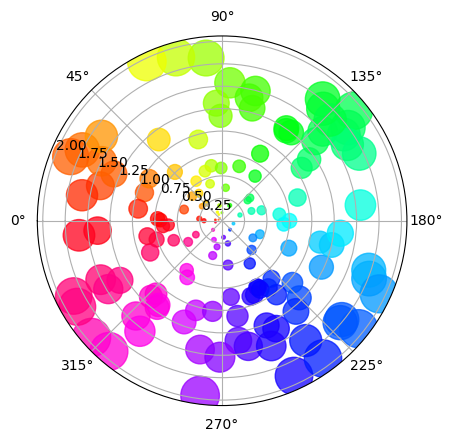

In [44]:
# example of matplptlib website
N = 150
r = 2 * np.random.rand(N)

#print(f"Radius: {r}")
max_r = max(r)
theta = 2 * np.pi * np.random.rand(N)
area = 200 * r**2
colors = theta



angle_90 = np.radians(0)
x_90, y_90 = max_r * np.cos(angle_90), max_r*np.sin(angle_90)
x90_2nest = rel2Nest(x_90)
y90_2nest = rel2Nest(y_90)

angle_180 = np.radians(180)
x_180, y_180 = max_r * np.cos(angle_180), max_r*np.sin(angle_180)
x180_2nest = rel2Nest(x_180)
y180_2nest = rel2Nest(y_180)

fig = plt.figure()
ax = fig.add_subplot(projection='polar')
c = ax.scatter(theta, r, c=colors, s=area, cmap='hsv', alpha=0.75)
ax.set_theta_zero_location('W')
ax.set_theta_direction(-1)
print(x_90)
ax.annotate('', xy=(x_90, y_90), xytext=(0,0), arrowprops=dict(facecolor="k", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
#ax.annotate('', xy=(theta[-5], r[-5]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05)) # arrow to check working of arrow




In [45]:
def heading_workingout_at2(df, nest, condition, all=True):

    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    final_headings_list = []
    final_r_list = []
    """
    %% calculate distance (from middle) 
     [~,Pos]=cart2pol(Coordinates(:,2),Coordinates(:,3));
     
     %% cut the path when ants cross circle (r=Xcm) for the first time

        if max(Pos)>290
            DistBigger29=find(Pos>290);
            LastPoint=DistBigger29(1)-1;%coordinate at X cm
        else
            LastPoint=length(Pos);%last coordinate of path when shorter than X cm
        end
    """
    #angle_90 = np.radians(90)
    #x_90, y_90 = max_r * np.cos(angle_90), max_r*np.sin(angle_90)
    #x90_2nest = rel2Nest(x_90)
    #y90_2nest = rel2Nest(y_90)
    
    #angle_180 = np.radians(180)
    #x_180, y_180 = max_r * np.cos(angle_180), max_r*np.sin(angle_180)
    #x180_2nest = rel2Nest(x_180)
    #y180_2nest = rel2Nest(y_180)

    fig = plt.figure(figsize=(10, 10)) #10, 10
    
    ax = fig.add_subplot(projection='polar') # set to polar plot
    #ax.set_theta_direction(-1)
    #ax.set_theta_zero_location("W") # set the nest (0) to the west pos
    ax.set_thetagrids(np.arange(0, 360, 30),
    labels=['180°', '150°', '120°', '90°', '60°', '30°',
         '0°', '330°', '300°', '270°', '240°', '210°'])
    
    for id in unique_ids:
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x'])
        _y =  np.array(usedf['y'])

        theta, r = cart2pola(_x,_y) # need x and y in array. converts to polar coordinates
        #scatter2 = ax.scatter(theta, r, alpha=0.4, s= 16, cmap="viridis") # plot the final heading directions
        # Cornelia like path cutting  between 2 and 29 cm
        if max(r) >290:
            distBigger29 = np.where(r>290)
            lastpoint = distBigger29[0][-1]
            #print(f"last point {lastpoint}")
            
        else:
            lastpoint = len(r)
            #print(f"last point {lastpoint}")
        """
        %% position where ants cross circle (r=Xcm) for the first time to exclude initial mess
        if max(Pos)>20
            DistBigger20=find(Pos>20);
            FirstPoint=DistBigger20(1);
        else
            FirstPoint=NaN;    
        end
        """
        #print(type(r))
        if max(r)>20:
            distBigger20 = np.where(r>20)
            #print(f"distbigger20 {distBigger20}, {type(distBigger20)}")
            firstPoint = distBigger20[0][0]
            #print(f"first point {firstPoint}, {type(firstPoint)}")
        else:
            firstPoint = 0
        # trim the path to between firstpoint and lastpoint
        """
        Xcut=Coordinates(FirstPoint:LastPoint,2);
        Ycut=Coordinates(FirstPoint:LastPoint,3);
        Tcut=Coordinates(FirstPoint:LastPoint,1);
        """
        x_cut = _x[firstPoint: lastpoint]
        y_cut = _y[firstPoint: lastpoint]
        
        #theta, r = cart2pola(x_cut, y_cut)
        #degrees = theta*180/np.pi # converts from radians to degrees
        
        finalpoint = theta[-1]
        #finalpoint = degrees[-1]
        #finalpoint = rel2Nest(finalpoint)
        
        final_headings_list.append(finalpoint)
        final_r = r[-1]
        #final_r = rel2Nest(final_r)
        final_r_list.append(final_r)

    mean_heading = np.mean(final_headings_list)
    mean_std = np.std(final_headings_list)
    abs_headings = [abs(i) for i in final_headings_list]
    mean_SEM = np.std(abs_headings)/np.sqrt(len(abs_headings)) #
    print(f"mean std {mean_std}")
    median_heading = np.median(final_headings_list)
    
    
    print(f" final headings list {final_headings_list}")
        
    scatter2 = ax.scatter(final_headings_list, final_r_list, alpha=0.4, s= 16, cmap="gist_rainbow") # plot the final heading directions
     
    
    
    #ax.annotate('', xy=(0, 290), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #ax.annotate('', xy=(mean_heading, final_r_list[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #ax.annotate('', xy=(x_180, 290), xytext=(0,0), arrowprops=dict(facecolor="k", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #ax.annotate('', xy=(mean_std, final_r_list[-1]), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #ax.annotate('', xy=(x90_2nest, 290), xytext=(0,0), arrowprops=dict(facecolor="k", shrink=0.05, alpha=0.6)) # arrow to check working of arrow

    #ax.annotate('', xy=(-mean_std, final_r_list[-1]), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=0.6)) # arrow to check working of arrow

    #ax.annotate('', xy=(mean_SEM, 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #ax.annotate('', xy=(-mean_SEM, 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    print(f"mean sem {mean_SEM}")

    ax.grid(True)
    plt.show()

heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV")
        

NameError: name 'heading_workingout' is not defined

In [ ]:
# final heading diretion
# heading direction at multiple points following path exact.
def rel2Nest(polar_pos):
    if polar_pos >=0:
        polar_pos_rel2Nest = 180 - polar_pos # relative to nest dir
    else:
        polar_pos_rel2Nest = -180 - polar_pos
    return polar_pos_rel2Nest

def heading_directions_at1(df, nest, condition, all=True):

    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    final_headings_list = []
    final_r_list = []


    for id in unique_ids:
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x'])
        _y =  np.array(usedf['y'])

        theta, r = cart2pola(_x,_y) # need x and y in array. converts to polar coordinates
        
        #degrees = theta*180/np.pi # converts from radians to degrees
        final_heading = theta[-1]#degrees[-1] # last heading = final heading dir
        
        final_heading = rel2Nest(final_heading)

        #print(f"Final heading for {id} : {final_heading}")
        #print(f"Final heading rel to nest for {id} : {final_heading_rel2Nest}")
        final_headings_list.append(final_heading) #final_heading_rel2Nest
        final_r = r[-1]
        #final_r = rel2Nest(final_r)
        final_r_list.append(final_r)
        

    mean_heading = np.mean(final_headings_list)
    
    mean_std = np.std(final_headings_list)
    print(f"mean std {mean_std}")
    median_heading = np.median(final_headings_list)
    
    max_r = max(final_r_list)
    print(f"mean heading : {mean_heading}, max r : {max_r}")
    
    print(f"final heading list:{final_headings_list}")
    # plotting the final heading directions
    print(len(final_headings_list), len(range(len(final_headings_list) -1)))
    fig = plt.figure(figsize=(10, 10)) #10, 10
    data_point = -30
    print(f"final_r_list[data_point] {final_r_list[data_point]}")
    ax = fig.add_subplot(projection='polar') # set to polar plot
    ax.set_theta_direction(-1)
    
    scatter2 = ax.scatter(final_headings_list, final_r_list, alpha=0.4, s= 16, cmap="gist_rainbow") # plot the final heading directions
    ax.set_theta_zero_location("W") # set the nest (0) to the west pos
    
    angle_90 = np.radians(90)
    angle_180 = np.radians(180)
    x_90, y_90 = max_r * np.cos(angle_90), max_r*np.sin(angle_90)
    x90_2nest = rel2Nest(x_90)
    y90_2nest = rel2Nest(y_90)
    x_180, y_180 = max_r * np.cos(angle_180), max_r*np.sin(angle_180)
    x180_2nest = rel2Nest(x_180)
    y180_2nest = rel2Nest(y_180)
    
    #ax.annotate('', xy=(mean_heading, max_r), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05))
    #ax.annotate('', xy=(median_heading, max_r-60), xytext=(0,0),arrowprops=dict(facecolor="skyblue", shrink=0.05))
    #ax.annotate('', xy=(mean_std, final_r_list[data_point]), xytext=(0,0), arrowprops=dict(facecolor="purple", shrink=0.05))
    #ax.annotate('', xy=(-mean_std, final_r_list[data_point]), xytext=(0,0), arrowprops=dict(facecolor="purple", shrink=0.05))
    #ax.arrow()
    #ax.annotate('', xy=(0, 250), xytext=(0,0), arrowprops=dict(facecolor="red")) # arrow to indicate Nest
    #ax.annotate('', xy=(2900, 250), xytext=(0,0) ,arrowprops=dict(facecolor="red")) # arrow to check working of arrow, should point W
    #ax.annotate('', xy=(300, 250), xytext=(0,0) ,arrowprops=dict(facecolor="red"))
    #ax.annotate('', xy=(350, 250), xytext=(0,0) ,arrowprops=dict(facecolor="red"))
    #ax.annotate('', xy=(355, 250), xytext=(0,0) ,arrowprops=dict(facecolor="red"))
    # more arrows that should point to E, N, S
    #ax.annotate('', xy=(x90_2nest, y90_2nest), xytext=(0,0),arrowprops=dict(facecolor="orchid", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    ax.annotate('', xy=(x180_2nest, y180_2nest), xytext=(0,0), arrowprops=dict(facecolor="lightpink", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #ax.annotate('', xy=(270, 200), xytext=(0,0), arrowprops=dict(facecolor="purple", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    # changing the y in xy var, seems to affect the length of the arrow, not direction. x affects direction.
    # so WHY are they not pointing in directions marked by the axis?
    ax.grid(True)

    #ax.set_thetagrids(np.arange(0, 360, 30),
    #                  labels=['0°', '330°', '300°', '270°', '240°', '210°',
    #                         '180°', '150°', '120°', '90°', '60°', '30°'])
    # labels=['180°', '150°', '120°', '90°', '60°', '30°',
    #                         '0°', '330°', '300°', '270°', '240°', '210°']
    fig.suptitle(f"{np.unique(newdf['Nest'])} {np.unique(newdf['Condition'])} \n Mean Heading : {mean_heading} \n Median Heading : {median_heading}")
    plt.show()

    print(f"Final heading list: {final_headings_list}")
    print(f"Final mean heading list: {mean_heading}, median heading {median_heading}")


# 'Wigwam', "Off-route 1 ZV"
heading_directions(antTrackDF, 'Wigwam', "On-route 1 ZV")

closer
but had hack to match what cornelia had.

NO HACKS ALLOWED!

to do:
make a list of all the transformations already applied to the data
Amani code
cornelia code


In [ ]:
def heading_workingout(df, nest, condition, all=True):

    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    final_headings_list = []
    final_r_list = []
    final_headings_fullpath_list = []

    fig = plt.figure(figsize=(10, 10)) #10, 10
    
    ax = fig.add_subplot(projection='polar') # set to polar plot
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    #ax.set_thetagrids(np.arange(0, 360, 30), # rotating the axes wITHOUT rotating the data
    #labels=['180°', '150°', '120°', '90°', '60°', '30°',
    #     '0°', '330°', '300°', '270°', '240°', '210°'])
    
    for id in unique_ids:
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x']) # getting out our cartesian coordinates from the df
        _y =  np.array(usedf['y'])

        theta_full, r_full = cart2pola(_x,_y) # FULL PATH # need x and y in array. converts to polar coordinates
        
        #scatter2 = ax.scatter(theta_full, r_full, alpha=0.4, s= 16, cmap="viridis") # plotting the full paths
        
        final_headings_fullpath_list.append(theta_full[-1]+np.pi) # fullpath final heading dir
        
        # Cornelia like path cutting  between 2 and 29 cm
        if max(r_full) >290:
            distBigger29 = np.where(r_full>290) # getting all points the path is further than 29cm from the center of the board
            lastpoint = distBigger29[0][-1] # getting the last time this happens (final heading)
            #print(f"last point {lastpoint}")
        else:
            lastpoint = len(r_full) # if the ant never makes it to 29cm from center, take the last pos of the ant
            
        if max(r_full)>20:
            distBigger20 = np.where(r_full>20) # same as above but getting the the point the ant passes 2cm from the center 
            firstPoint = distBigger20[0][0] # taking the first point this happens
        else:
            firstPoint = 0

        x_cut = _x[firstPoint: lastpoint] # using the above indices to cut the path between 2cm and 29cm
        y_cut = _y[firstPoint: lastpoint]
        theta, r = cart2pola(x_cut, y_cut) # CUT PATH # transform to pola coordinates
        #theta = theta * (180/np.pi)
        degrees = theta*180/np.pi 
        #finalpoint = theta[-1] # taking the final point in RADIANS
        finalpoint = degrees[-1]
        #finalpoint = np.pi - theta[-1] # REFLECTION not rotation! not good.
        final_headings_list.append(finalpoint) # Append to final headings list (once per ant)
        final_r = r[-1] # final radius len
        #final_r = rel2Nest(final_r)
        final_r_list.append(final_r) # append to final radius list
        
    # calc the mean of all final heading directions
    mean_heading = np.mean(final_headings_list) #np.radians(polar_offset(np.mean(final_headings_list))) 
    print(f" mean heading : {mean_heading}")
    mean_fullpath_heading = np.mean(final_headings_fullpath_list)
    
    # taking the standard deviation of the final headings list
    mean_std = np.std(final_headings_list)
    print(f" mean std {mean_std}")

    # SEM 
    abs_headings = [abs(i) for i in final_headings_list] # converting the headings to absolute values (no negatives)
    mean_SEM = np.std(abs_headings)/np.sqrt(len(abs_headings)) # SEM calc
    print(f" mean SEM {mean_SEM}")

    # calc the median final heading
    median_heading = np.median(final_headings_list)
    print(f" median heading {median_heading}")
    
    
    print(f" final headings list {final_headings_list}") # print final headings to see if the arrows look right
        
    scatter2 = ax.scatter(final_headings_list, final_r_list, alpha=0.4, s= 16, cmap="gist_rainbow") # plot the final heading directions
     
    angle_0 = np.radians(0) # Nest is at 0 # polar_offset(0)
    
    #x_180, y_180 = max_r * np.cos(angle_180), max_r*np.sin(angle_180)
    #x180_2nest = rel2Nest(x_180)
    #y180_2nest = rel2Nest(y_180)
    
    # arrow pointing to nest (0)
    ax.annotate('', xy=(angle_0, 290), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    # arrow pointing to the mean of cut paths DARK BLUE
    ax.annotate('', xy=((mean_heading), final_r_list[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    # arrow pointing to mean of the full paths LIGHT BLUE
    ax.annotate('', xy=(mean_fullpath_heading, 290), xytext=(0,0), arrowprops=dict(facecolor="lightblue", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    # arrow pointing to pos 1 std away ORANGE
    ax.annotate('', xy=(mean_std, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    #print(f"rad(pol_off(mean_sem) {(np.radians(polar_offset(mean_SEM)))}")
    ax.annotate('', xy=(-mean_std, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=0.6)) # arrow to check working of arrow

    # arrow pointing to pos SEM  YELLOW
    ax.annotate('', xy=((mean_SEM), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    # arrow pointing to neg SEM  YELLOW
    ax.annotate('', xy=((-mean_SEM), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=0.6)) # arrow to check working of arrow

    print(f"mean sem {mean_SEM}") # see what the mean SEM is to check if arrow looks right

    ax.grid(True)
    plt.show()

heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV")
        

#### attempt after paper distraction 10425

In [ ]:
# code from help with claude
# ISSue was in transofmring the x,y coords (matlab) from those of video/im coords to x,y -
# - the fixed points [1, 2, 3, 4] were set to match [-270 0,0 270, 270 0,0 -270]
# Fixed point 1 IS the nest direction
# this sets all coordinares relating to the nest on the left side of cartesian axis.
# the transformed data Expects the nest to be on the left

# plt.polar puts 0 degrees  axis label on the right.
# we want the 0 degress axis label to re

 mean heading  theta : 3.199384445690141
mean heading DEGREE : 3.7334558971757046
 mean std  theta 1.3457150942194738
mean std DEGREE : 2.059884664135381
 mean SEM  theta 0.3239026052116873
mean SEM DEGREE : 0.3045314088796076
 median heading  theta -1.0982707682083643
median heading DEGREE : -62.92627978092999
mean sem 0.3239026052116873


/tmp/ipykernel_164016/689016250.py:137: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter_theta = ax.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='o',s= 16, cmap="gist_rainbow") # plot the final heading directions


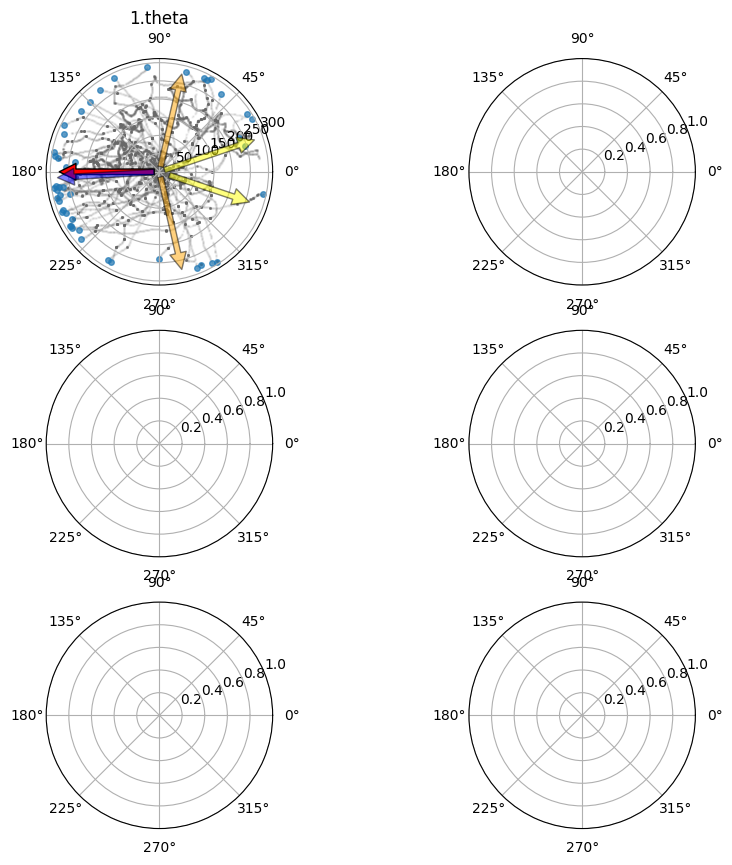

In [48]:
def heading_workingout(df, nest, condition, all=True):
    # 240425 - using scipy circular stats functions
    alphaval_path = 0.05
    alpha_finalp = 0.7
    alpha_val = 0.5
    mean_heading_overall = []
    
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    final_headings_list_theta = []
    final_headings_list_degree = []
    final_r_list_theta = []
    final_r_list_degree = []
    final_headings_fullpath_list = []

    fig = plt.figure(figsize=(10, 10)) #10, 10
    
    ax = fig.add_subplot(321,projection='polar') # set to polar plot 221
    #ax.set_theta_zero_location('W')
    #ax.set_theta_direction(-1)
    ax2 = fig.add_subplot(322,projection='polar') # row, col, index 222
    #ax2.set_theta_zero_location('W')
    
    ax3 = fig.add_subplot(323,projection='polar') # row, col, index
    #ax2.set_theta_zero_location('W')
    ax4 = fig.add_subplot(324,projection='polar') # row, col, index
    #ax2.set_theta_zero_location('W')
    ax5 = fig.add_subplot(325, projection='polar')
    #ax5.set_theta_zero_location('W')
    #ax5.set_theta_direction(-1)
    ax6 = fig.add_subplot(326, projection='polar')
    #ax6.set_theta_zero_location('W')
    #ax6.set_theta_direction(-1)
    
    #ax2.set_theta_direction(-1)
    #ax.set_thetagrids(np.arange(0, 360, 30), # rotating the axes wITHOUT rotating the data
    #labels=['180°', '150°', '120°', '90°', '60°', '30°',
    #     '0°', '330°', '300°', '270°', '240°', '210°'])
    
    for id in unique_ids:
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x']) # getting out our cartesian coordinates from the df
        _y =  np.array(usedf['y'])

        theta_full, r_full = cart2pola(_x,_y) # FULL PATH # need x and y in array. converts to polar coordinates
        #print(f"len of full paths {len(theta_full)}")
        #scatter2 = ax.scatter(theta_full, r_full, alpha=0.4, s= 16, cmap="viridis") # plotting the full paths
        theta_full = np.rad2deg(theta_full)
        #theta_full = [rel2Nest(t) for t in theta_full]
        theta_full = np.deg2rad(theta_full)
        final_headings_fullpath_list.append(theta_full[-1]) # fullpath final heading dir
        #ax.scatter(theta_full, r_full, c='k', s=0.7, alpha=alphaval_path)
        
        # Cornelia - path cutting  between 2 and 29 cm
        if max(r_full) >290:
            distBigger29 = np.where(r_full>290) # getting all points the path is further than 29cm from the center of the board
            lastpoint = distBigger29[0][-1] # getting the last time this happens (final heading)
            #print(f"last point {lastpoint}")
        else:
            lastpoint = len(r_full) # if the ant never makes it to 29cm from center, take the last pos of the ant
            
        if max(r_full)>20:
            distBigger20 = np.where(r_full>20) # same as above but getting the the point the ant passes 2cm from the center 
            firstPoint = distBigger20[0][0] # taking the first point this happens
        else:
            firstPoint = 0

        x_cut = _x[firstPoint: lastpoint] # using the above indices to cut the path between 2cm and 29cm
        y_cut = _y[firstPoint: lastpoint]
        theta, r = cart2pola(x_cut, y_cut) # CUT PATH # transform to pola coordinates
        
        #print(f"len of cut paths {len(theta)}")
        #theta = theta * (180/np.pi)
        degrees = np.rad2deg(theta)#theta*180/np.pi 
        #degrees = [rel2Nest(i) for i in degrees]
        finalpoint_theta = theta[-1] # taking the final point in RADIANS
        finalpoint_degree = degrees[-1]
        

        #print(f"type degee {type(degrees)}, {degrees}")
        mean_head = np.mean(degrees)
        mean_heading_overall.append(mean_head)
        
        #finalpoint_degree = rel2Nest(finalpoint_degree)
        finalpoint_degree2theta = (finalpoint_degree *np.pi) /180

        ax.scatter(theta_full, r_full, c='dimgray', s=0.7, alpha=alphaval_path)
        #ax2.scatter(theta_full, r_full, c='dimgray', s=0.7, alpha=alphaval_path)
        #ax3.scatter(theta, r, c='dimgray', s=0.7, alpha=alphaval_path)
        #ax4.scatter(theta, r, c='dimgray', s=0.7, alpha=alphaval_path)
        #ax5.scatter(theta_full, r_full, c='dimgray', s=0.7, alpha=alphaval_path)
        #ax6.scatter(theta_full, r_full, c='dimgray', s=0.7, alpha=alphaval_path)
        
        #finalpoint = np.pi - theta[-1] # REFLECTION not rotation! not good.
        final_headings_list_theta.append(finalpoint_degree2theta) #finalpoint_theta Append to final headings list (once per ant)
        final_headings_list_degree.append(finalpoint_degree)
        
        final_r_theta = r[-1] # final radius len
        final_r_list_theta.append(final_r_theta) # append to final radius list
        final_r_list_degree.append(final_r_theta)
        
    # calc the mean of all final heading directions
    mean_heading_theta = scipy.stats.circmean(final_headings_list_theta)#np.mean(final_headings_list_theta) #np.radians(polar_offset(np.mean(final_headings_list))) 
    #print(f" mean heading  theta : {mean_heading_theta}")
    #mean_fullpath_heading = np.mean(final_headings_fullpath_list)
    #mean_heading_degree = np.mean(final_headings_list_degree)
    mean_fullpath_heading = scipy.stats.circmean(final_headings_fullpath_list)
    mean_heading_degree = scipy.stats.circmean(final_headings_list_degree)
    print(f"mean heading DEGREE : {mean_heading_degree}")
    #print("mean full path", mean_fullpath_heading)
    
    # taking the standard deviation of the final headings list
    mean_std_theta = scipy.stats.circstd(final_headings_list_theta)#np.std(final_headings_list_theta)
    print(f" mean std  theta {mean_std_theta}")
    mean_std_degree = scipy.stats.circstd(final_headings_list_degree)#np.std(final_headings_list_degree)
    print(f"mean std DEGREE : {mean_std_degree}")

    # SEM 
    abs_headings_theta = [abs(i) for i in final_headings_list_theta] # converting the headings to absolute values (no negatives)
    mean_SEM_theta = scipy.stats.circmean(abs_headings_theta)/np.sqrt(len(abs_headings_theta))#np.std(abs_headings_theta)/np.sqrt(len(abs_headings_theta)) # SEM calc
    print(f" mean SEM  theta {mean_SEM_theta}")
    abs_headings_degree =[abs(i) for i in final_headings_list_degree]
    mean_SEM_degree = scipy.stats.circmean(abs_headings_degree)/np.sqrt(len(abs_headings_degree))#np.std(abs_headings_degree)/np.sqrt(len(abs_headings_degree))
    print(f"mean SEM DEGREE : {mean_SEM_degree}")

    # calc the median final heading
    median_heading_theta = np.median(final_headings_list_theta)
    print(f" median heading  theta {median_heading_theta}")
    median_headings_degree = np.median(final_headings_list_degree)
    print(f"median heading DEGREE : {median_headings_degree}")
    
    
    #print(f" final headings list {final_headings_list_theta}") # print final headings to see if the arrows look right
    #print(f"FULLPATH final headings list {final_headings_fullpath_list}")
    
    scatter_theta = ax.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='o',s= 16, cmap="gist_rainbow") # plot the final heading directions
    #scatter_theta_notrans = ax3.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp,marker='x', s= 16, cmap="gist_rainbow") 
    #scatter_degree = ax2.scatter(final_headings_list_degree, final_r_list_degree, alpha=alpha_finalp,marker='<', s= 16, cmap="gist_rainbow")
    #scatter_degree_notrans = ax4.scatter(final_headings_list_degree, final_r_list_degree, alpha=alpha_finalp,marker='x', s= 16, cmap="gist_rainbow")
    
    #scatter_theta_rev = ax5.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp,marker='x', s= 16, cmap="gist_rainbow")
    #scatter_degre_rec = ax6.scatter(final_headings_list_degree, final_r_list_degree, alpha=alpha_finalp,marker='x', s= 16, cmap="gist_rainbow")
    nestDir = np.radians(180) # Nest is at 0 # polar_offset(0)
    ax.title.set_text('1.theta')
    #ax2.title.set_text('2. degree')
    #ax3.title.set_text('3. theta no axis shift')
    #ax4.title.set_text('4. degree no axis shift')
    #ax5.title.set_text('5. theta axis shift, reverse')
    #ax6.title.set_text('6. degree axis shirt, reverse')
    # ax1.title.set_text
    #x_180, y_180 = max_r * np.cos(angle_180), max_r*np.sin(angle_180)
    #x180_2nest = rel2Nest(x_180)
    #y180_2nest = rel2Nest(y_180)
    
    # arrow pointing to nest (0)
    ax.annotate('', xy=(nestDir, 290), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05)) # arrow to check working of arrow
    # arrow pointing to the mean of cut paths DARK BLUE
    ax.annotate('', xy=((mean_heading_theta), final_r_list_theta[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    # arrow pointing to mean of the full paths LIGHT BLUE
    #ax.annotate('', xy=(mean_fullpath_heading, 290), xytext=(0,0), arrowprops=dict(facecolor="lightblue", shrink=0.05, alpha=0.6)) # arrow to check working of arrow
    # arrow pointing to pos 1 std away ORANGE
    ax.annotate('', xy=(mean_std_theta, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    #print(f"rad(pol_off(mean_sem) {(np.radians(polar_offset(mean_SEM)))}")
    ax.annotate('', xy=(-mean_std_theta, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    # arrow pointing to pos SEM  YELLOW
    ax.annotate('', xy=((mean_SEM_theta), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    # arrow pointing to neg SEM  YELLOW
    ax.annotate('', xy=((-mean_SEM_theta), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=alpha_val)) # arrow to check working of arrow

    """ax2.annotate('', xy=(nestDir, 299), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax2.annotate('', xy=((mean_heading_degree), final_r_list_theta[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax2.annotate('', xy=((mean_SEM_degree), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax2.annotate('', xy=((-mean_SEM_degree), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=alpha_val)) # arrow to check working of arrow
    ax2.annotate('', xy=(mean_std_degree, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax2.annotate('', xy=(-mean_std_degree, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow


    ax3.annotate('', xy=(nestDir, 299), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax3.annotate('', xy=((mean_heading_theta), final_r_list_theta[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax3.annotate('', xy=((mean_SEM_theta), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax3.annotate('', xy=((-mean_SEM_theta), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=alpha_val)) # arrow to check working of arrow
    ax3.annotate('', xy=(mean_std_theta, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax3.annotate('', xy=(-mean_std_theta, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow

    ax4.annotate('', xy=(nestDir, 299), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax4.annotate('', xy=((mean_heading_degree), final_r_list_theta[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax4.annotate('', xy=((mean_SEM_degree), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax4.annotate('', xy=((-mean_SEM_degree), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=alpha_val)) # arrow to check working of arrow
    ax4.annotate('', xy=(mean_std_degree, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax4.annotate('', xy=(-mean_std_degree, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    
    ax5.annotate('', xy=(nestDir, 299), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax5.annotate('', xy=((mean_heading_theta), final_r_list_theta[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax5.annotate('', xy=((mean_SEM_theta), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax5.annotate('', xy=((-mean_SEM_theta), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=alpha_val)) # arrow to check working of arrow
    ax5.annotate('', xy=(mean_std_theta, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax5.annotate('', xy=(-mean_std_theta, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow

    ax6.annotate('', xy=(nestDir, 299), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax6.annotate('', xy=((mean_heading_degree), final_r_list_theta[-1]), xytext=(0,0), arrowprops=dict(facecolor="blue", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax6.annotate('', xy=((mean_SEM_degree), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax6.annotate('', xy=((-mean_SEM_degree), 290), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=0.10, alpha=alpha_val)) # arrow to check working of arrow
    ax6.annotate('', xy=(mean_std_degree, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow
    ax6.annotate('', xy=(-mean_std_degree, 290), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=0.05, alpha=alpha_val)) # arrow to check working of arrow"""
    print(f"mean sem {mean_SEM_theta}") # see what the mean SEM is to check if arrow looks right

    ax.grid(True)
    plt.show()
    return mean_heading_overall, final_headings_list_degree
meanheading, finalheadings = heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV")
        

 mean heading   : 4.209336315209403
 mean heading   : 1.907299872481373
 mean heading   : 1.692842935256547
 mean heading   : 2.131072668364288
 mean heading   : 5.414915902449275
 mean heading   : 2.2261079301341358
 mean heading   : 0.7015267628359986
 mean heading   : 3.2624236929182104
 mean heading   : 1.3630970980451829
 mean heading   : 3.9094592127826715
 mean heading   : 4.22340404414687
 mean heading   : 4.744081422113042
 mean heading   : 1.7295722358435137
 mean heading   : 5.461839398041534
 mean heading   : 3.860273674330784
 mean heading   : 3.0427053942329065
 mean heading   : 1.4804469063051706
 mean heading   : 2.148074592127303
 mean heading   : 0.5622456159577546
 mean heading   : 4.035483997697474
 mean heading   : 2.4122860588835255
 mean heading   : 4.889466689205704
 mean heading   : 0.1359720887018208
 mean heading   : 2.460499054639346
 mean heading   : 0.024199857765370484
 mean heading   : 0.9054382948059441
 mean heading   : 3.5038511795430973
 mean heading

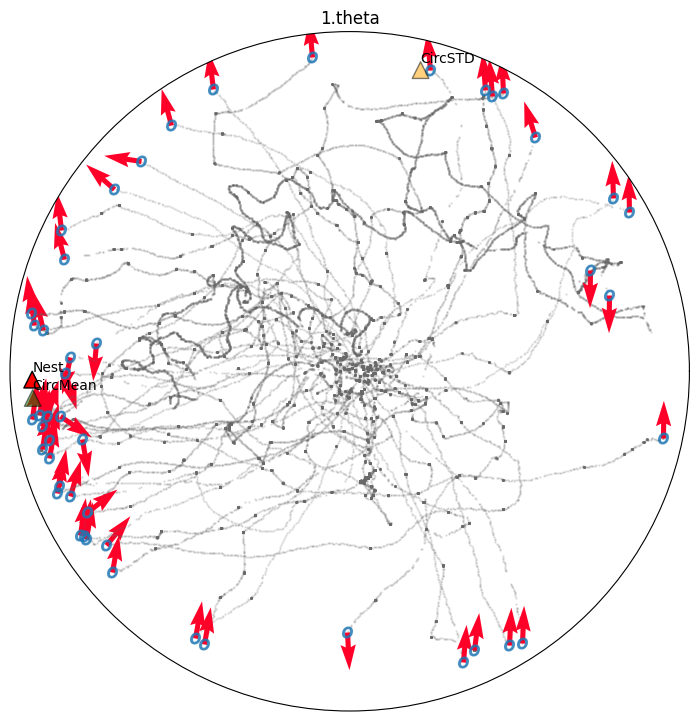

In [65]:
meanheading, finalheadings = heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV")

In [61]:
np.mean(meanheading)

-10.438681775082863

In [62]:
np.mean(finalheadings)

-29.88090463924357

In [ ]:
def add_plot_arrows(ax,final_r_list_theta,mean_heading_theta,mean_std_theta,mean_SEM_theta):
    # arrow pointing to nest (180)
    y_val = final_r_list_theta[-1]
    aro_w = 2
    shink_val = #0.05
    alpha_val = 0.5
    nestDir = np.radians(180) # Nest is at 0 # polar_offset(0)
    ax.annotate('', xy=(nestDir, y_val), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=shink_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to the mean of cut paths DARK BLUE
    if mean_heading_theta is not None:
        ax.annotate('', xy=((mean_heading_theta), y_val), xytext=(0,0), arrowprops=dict(facecolor="indigo", shrink=shink_val, alpha=alpha_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to pos 1 std away ORANGE
    #ax.annotate('', xy=(mean_std_theta, y_val), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=shink_val, alpha=alpha_val, width=aro_w)) # arrow to check working of arrow
    #print(f"rad(pol_off(mean_sem) {(np.radians(polar_offset(mean_SEM)))}")
    #ax.annotate('', xy=(-mean_std_theta, y_val), xytext=(0,0), arrowprops=dict(facecolor="orange", shrink=shink_val, alpha=alpha_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to pos SEM  YELLOW
    #ax.annotate('', xy=((mean_SEM_theta), y_val), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=shink_val, alpha=alpha_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to neg SEM  YELLOW
    #ax.annotate('', xy=((-mean_SEM_theta), y_val), xytext=(0,0), arrowprops=dict(facecolor="yellow", shrink=shink_val, alpha=alpha_val, width=aro_w)) # arrow to check working of arrow


In [ ]:
"""def add_plot_arrows(ax,nestdeg=180, **args:tuple):
    # arrow pointing to nest (180)
    y_val = final_r_list_theta[-1]
    aro_w = 2
    shink_val = 1#0.05
    alpha_val = 0.5
    nestDir = np.radians(180) # Nest is at 0 # polar_offset(0)
    ax.annotate('', xy=(nestDir, y_val), xytext=(0,0), arrowprops=dict(facecolor="red", shrink=shink_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to the mean of cut paths DARK BLUE
    for idx, arg in enumerate(args):
        ax.annotate('', xy=(arg[0], y_val), xytext=(0,0), arrowprops=dict(facecolor=arg[1], shrink=shrink_val, alpha=alpha_val,width=aro_w))"""

### same as above, cleaner
added in Rayleigh test.

rayleigh directedness res  0.00030034494856347947
circ mean heading theta 3.199384445690141
 circ mean std  theta 1.3457150942194736


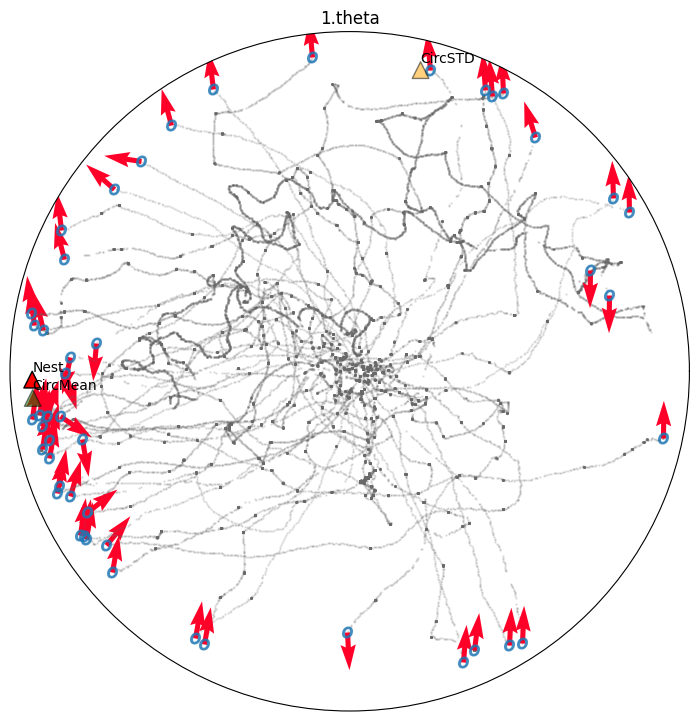

([241.17720541264833,
  109.28023295902278,
  96.99275556873822,
  122.10146973295625,
  310.25182762861687,
  127.54658913728952,
  40.19452272597777,
  186.92310858769758,
  78.09971078451916,
  223.99551307098434,
  241.98322690809925,
  271.81584315349886,
  99.09718947683878,
  312.94034588605405,
  221.17738930461275,
  174.33417739123485,
  84.8233595244859,
  123.0756082081802,
  32.214300844112664,
  231.2162013606465,
  138.2138101522728,
  280.1458053612906,
  7.7906268141927955,
  140.97621132676346,
  1.3865497147726202,
  51.8777929019026,
  200.75588462975472,
  213.7870945416969,
  167.65804567248347,
  252.0254254265109,
  323.7813299155761,
  307.15465898210323,
  288.6806882413922,
  117.8121302538242,
  148.55580743444753,
  309.69858040209976,
  308.9970342639014,
  286.9017000309709,
  196.55786231457935,
  250.94770822604863,
  38.76799805426854,
  197.40733709364395,
  41.07251363623757,
  187.3716324223753,
  181.0628509456104,
  179.69164467003463,
  192.21365

In [66]:
def get_circmean(headingslist, specify=""):
        mean_heading = scipy.stats.circmean(headingslist)#np.mean(final_headings_list_theta) #np.radians(polar_offset(np.mean(final_headings_list))) 
        #print(f" mean heading  {specify} : {mean_heading}")
        return mean_heading

def cut_path(r_full, x, y):
    # Cornelia - path cutting  between 2 and 29 cm
    if max(r_full) >290:
        distBigger29 = np.where(r_full>290) # getting all points the path is further than 29cm from the center of the board
        lastpoint = distBigger29[0][-1] # getting the last time this happens (final heading)
        #print(f"last point {lastpoint}")
    else:
        lastpoint = len(r_full) # if the ant never makes it to 29cm from center, take the last pos of the ant
        
    if max(r_full)>20:
        distBigger20 = np.where(r_full>20) # same as above but getting the the point the ant passes 2cm from the center 
        firstPoint = distBigger20[0][0] # taking the first point this happens
    else:
        firstPoint = 0

    x_cut = x[firstPoint: lastpoint] # using the above indices to cut the path between 2cm and 29cm
    y_cut = y[firstPoint: lastpoint]
    return x_cut, y_cut

def add_plot_arrows(ax, nestdeg=180, *args:tuple):
    # takes in axes to plot on; direction of nest (in degrees); any number of additional arrows - must be in a tuple of (angle, "colour")
    # adds a red arrow in direction of nest
    # adds
    y_val = 290
    aro_w = 2
    shrink_val = 0
    alpha_val = 0.5
    nestDir = np.radians(180) # Nest is at 0 # polar_offset(0)
    ax.annotate('Nest', xy=(nestDir, y_val), xytext=(nestDir,y_val), arrowprops=dict(facecolor="red", shrink=shrink_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to the mean of cut paths DARK BLUE
    for idx, arg in enumerate(args):
        ax.annotate(f"{arg[2]}", xy=(arg[0], y_val), xytext=(arg[0], y_val), arrowprops=dict(facecolor=arg[1], shrink=shrink_val, alpha=alpha_val,width=aro_w))
    

def delta_pos(usedf,_x, _y):
    r = np.sqrt(_x**2, _y**2)
    usedf['dx'] = usedf['x'].diff(periods=1) # periods = 1, take current row from following row
    usedf['dy'] = usedf['y'].diff(periods=1)
    return usedf, r

def headingdir_seyi(usedf):
    headingdirs=[]
    for idx, row in usedf.iterrows():
        #print(row)
        if row['dx'] is not None:
            angle = np.rad2deg(np.arctan2(row['dy'], row['dx']))
            headingdirs.append((180-angle) % 360) #180 is the offset, 360 scales between 0 & 360 degrees
    return headingdirs

    
def heading_workingout(df, nest, condition, all=True):
    # 240425 - using scipy circular stats functions
    # sample df by nest and condition type
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    # lists to hold final headings (radians or degrees)
    final_headings_list_theta = []
    final_headings_list_degree = []
    final_r_list_theta = []
    final_r_list_degree = []
    final_headings_fullpath_list = []
    final_xy = []
    meanheadindivs = []

    headings = []
    arrow_frames = -1
    # 'setting' vars for plotting
    alphaval_path = 0.15
    alpha_finalp = 0.7
    # set fig size
    fig = plt.figure(figsize=(30, 30)) #10, 10
    ax = fig.add_subplot(321,projection='polar') 


    for id in unique_ids:
        # subset df further by trial/ ant ID
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x']) # getting out our cartesian coordinates from the df
        _y =  np.array(usedf['y'])
        final_xy.append((_x[-1], _y[-1]))
        usedf, r_full = delta_pos(usedf,_x,_y)
        
        #theta_full = headingdir_seyi(usedf)


        
        theta_full, r_full = cart2pola(_x,_y)
        theta_full = [0 if maths.isnan(i) else i for i in theta_full]
        #print(f"theta full {type(theta_full)}, {len(theta_full)}")
        usedf['headings'] = theta_full
        #headings.append(usedf['headings'].to_numpy())
        #print(f"headings. {type(headings)}, {len(headings)}")
        h = get_circmean(theta_full)
        he = np.rad2deg(h)
        meanheadindivs.append(he)


        
        #print(theta_full)
        
        #theta_full, r_full = cart2pola(_x,_y) # FULL PATH converts to polar coordinates
        final_headings_fullpath_list.append(theta_full[-1]) # fullpath final heading dir
        
        # Cornelia - path cutting  between 2 and 29 cm
        x_cut, y_cut = cut_path(r_full, _x, _y)
        theta, r = cart2pola(x_cut, y_cut) # transform to pola coordinates

        degrees = np.rad2deg(theta)#theta*180/np.pi 
        finalpoint_theta = theta[-1] # taking the final point in RADIANS
        finalpoint_degree = degrees[-1]
        #print("fin point deg",(finalpoint_degree))
        finalpoint_degree2theta =  np.deg2rad(finalpoint_degree)

        #ax.scatter(theta_full, r_full, c='dimgray', s=0.7, alpha=alphaval_path)
        
        #print(f"theta full : {type(headings[6])}")
        
        #headings_main = headings[:arrow_frames]
        #print(type(theta_full[arrow_frames:][0]),theta_full[arrow_frames:][0])
        headings_end = theta_full[arrow_frames:][0]+180
        ax.scatter(theta_full[:arrow_frames], r_full[:arrow_frames], c='dimgray', s=0.7, alpha=alphaval_path)
        
        ax.quiver(theta[arrow_frames:], r[arrow_frames:],
                  np.sin(np.deg2rad(headings_end)),  
                  np.cos(np.deg2rad(r_full[arrow_frames:][0])),
                  usedf['frame'][arrow_frames:], 
                  ec='k', cmap="gist_rainbow")# headings_end[:] headings_end[:]
                  
        #print(f"finalpoint_degree {finalpoint_degree}, theta {finalpoint_theta}")
        #print(f"headings_end {headings_end}, theta {np.deg2rad(headings_end)}")
        
        # too messy with everything as arrows - have last 5 frames as arrows?

        final_headings_list_theta.append(finalpoint_degree2theta) #finalpoint_theta Append to final headings list (once per ant)
        final_headings_list_degree.append(finalpoint_degree)
        
        final_r_theta = r[-1] # final radius len
        final_r_list_theta.append(final_r_theta) # append to final radius list
        final_r_list_degree.append(final_r_theta)
    
    # Cornelia - calc circ mean if path is directed
    # rayleigh distribution - observed when overall magnitude is related to direction
    final_headings_list_theta_array = np.array(final_headings_list_theta)
    rayleigh_ans = astro.rayleightest(final_headings_list_theta_array)
    # calc the mean of all final heading directions    
    print("rayleigh directedness res ", rayleigh_ans)
    rayleigh_ans = float(rayleigh_ans)
    if rayleigh_ans <= 0.05:
        circmean_heading_theta = get_circmean(final_headings_list_theta)
        print(f"circ mean heading theta {circmean_heading_theta}")
        circmean_heading_degree = np.rad2deg(circmean_heading_theta)
    else:
        circmean_heading_theta = None

    # taking the standard deviation of the final headings list
    mean_std_theta = scipy.stats.circstd(final_headings_list_theta)#np.std(final_headings_list_theta)
    print(f" circ mean std  theta {mean_std_theta}")

    # SEM 
    #abs_headings_theta = [abs(i) for i in final_headings_list_theta] # converting the headings to absolute values (no negatives)
    #mean_SEM_theta = scipy.stats.circmean(abs_headings_theta)/np.sqrt(len(abs_headings_theta))#np.std(abs_headings_theta)/np.sqrt(len(abs_headings_theta)) # SEM calc
    #print(f" mean SEM  theta {mean_SEM_theta}")

    # calc the median final heading
    #median_heading_theta = np.median(final_headings_list_theta)
    #print(f" median heading  theta {median_heading_theta}")
    #ax.quiver(_x[arrow_frames:], _y[arrow_frames:], 
    #              np.sin(np.deg2rad(final_headings_list_degree+180)), #
    #              np.cos(np.deg2rad(final_headings_list_degree+180)),usedf['frame'][arrow_frames:], ec='k')# headings_end[:] headings_end[:]
    #print(f"final r len {len(final_r_list_theta)}")
    #print(f"final theta len {len(final_headings_list_theta)}")
    #print(f"final xy len {len(final_xy)}")
    #print(f"final x len {len(final_xy[0]), final_xy[0]}")
    #print(f"final y len {len(final_xy[1])}")
    
    #ax.quiver(final_xy[:][0], final_xy[:][1], # X, Y, U, V, C
    #              np.sin(final_headings_list_theta), #
    #              np.cos(final_r_list_theta),usedf['frame'][arrow_frames:], ec='k')
    
    scatter_theta = ax.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) # plot the final heading directions
    ax.title.set_text('1.theta')
    add_plot_arrows(ax,(final_r_list_theta, 'blue', "fin theta"),(circmean_heading_theta, 'green', "CircMean"),(mean_std_theta, 'orange', "CircSTD"))
    
    #print(f"mean sem {mean_SEM_theta}") # see what the mean SEM is to check if arrow looks right

    ax.grid(False)
    #ax.set_axis_off()
    plt.xticks([]) 
    plt.yticks([])
    plt.show()
    return meanheadindivs, circmean_heading_degree
heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV")
        

Functions

In [75]:

def get_circmean(headingslist, specify=""):
        mean_heading = scipy.stats.circmean(headingslist)#np.mean(final_headings_list_theta) #np.radians(polar_offset(np.mean(final_headings_list))) 
        print(f" mean heading  {specify} : {mean_heading}")
        return mean_heading

def cut_path(r_full, x, y, endcut=290, startcut=20):
    # Cornelia - path cutting  between 2 and 29 cm
    if max(r_full) >endcut:
        distBigger29 = np.where(r_full>endcut) # getting all points the path is further than 29cm from the center of the board
        lastpoint = distBigger29[0][-1] # getting the last time this happens (final heading)
        #print(f"last point {lastpoint}")
    else:
        lastpoint = len(r_full) # if the ant never makes it to 29cm from center, take the last pos of the ant
        
    if max(r_full)>startcut:
        distBigger20 = np.where(r_full>startcut) # same as above but getting the the point the ant passes 2cm from the center 
        firstPoint = distBigger20[0][0] # taking the first point this happens
    else:
        firstPoint = 0

    x_cut = x[firstPoint: lastpoint] # using the above indices to cut the path between 2cm and 29cm
    y_cut = y[firstPoint: lastpoint]
    return x_cut, y_cut

def add_plot_arrows(ax, nestdeg=180, *args:tuple):
    # takes in axes to plot on; direction of nest (in degrees); any number of additional arrows - must be in a tuple of (angle, "colour")
    # adds a red arrow in direction of nest
    # adds
    y_val = 290
    aro_w = 2
    shrink_val = 0
    alpha_val = 0.5
    nestDir = np.radians(180) # Nest is at 0 # polar_offset(0)
    ax.annotate('Nest', xy=(nestDir, y_val), xytext=(nestDir,y_val), arrowprops=dict(facecolor="red", shrink=shrink_val, width=aro_w)) # arrow to check working of arrow
    # arrow pointing to the mean of cut paths DARK BLUE
    for idx, arg in enumerate(args):
        ax.annotate(f"{arg[2]}", xy=(arg[0], y_val), xytext=(arg[0], y_val), arrowprops=dict(facecolor=arg[1], shrink=shrink_val, alpha=alpha_val,width=aro_w))
    

def delta_pos(usedf,_x, _y):
    r = np.sqrt(_x**2, _y**2)
    usedf['dx'] = usedf['x'].diff(periods=1) # periods = 1, take current row from following row
    usedf['dy'] = usedf['y'].diff(periods=1)
    return usedf, r

def headingdir_seyi(usedf):
    headingdirs=[]
    for idx, row in usedf.iterrows():
        #print(row)
        if row['dx'] is not None:
            angle = np.rad2deg(np.arctan2(row['dy'], row['dx']))
            headingdirs.append((180-angle) % 360) #180 is the offset, 360 scales between 0 & 360 degrees
    return headingdirs


def rayleigh_circmean(final_headings_list_theta):
    # Cornelia - calc circ mean if path is directed
    # rayleigh distribution - observed when overall magnitude is related to direction
    """ Takes in a list of theta heading directions in radians
        Outputs a circular mean IF rayleigh test score below 0.05"""
    rayleigh_ans = astro.rayleightest(np.array(final_headings_list_theta))
    # calc the mean of all final heading directions    
    print("rayleigh directedness res ", type(rayleigh_ans))
    if rayleigh_ans <= 0.05:
        circmean_heading_theta = get_circmean(final_headings_list_theta)
        print(f"circ mean heading theta {circmean_heading_theta}")
    else:
        circmean_heading_theta = None
    return circmean_heading_theta


def seyiheading_from_d(dy, dx, offset=90):
    if dx ==0 and dy == 0:
        heading = np.nan
        
    elif dx == 0 and dy > 0:
        heading = 0
        
    elif dx == 0 and dy < 0:
        heading = 180
        
    elif dx < 0 and dy == 0:
        heading = 270
        
    elif dx > 0 and dy == 0:
        heading = 90
            
    else:
        angle = np.rad2deg(np.arctan2(dy, dx))
        #need to use modulus % to scale things back to 0 to 360 degrees
        heading = (offset-angle) % 360
    
    return heading

rayleigh directedness res  <class 'numpy.float64'>
 mean heading   : 3.199384445690141
circ mean heading theta 3.199384445690141
 circ mean std  theta 1.3457150942194736


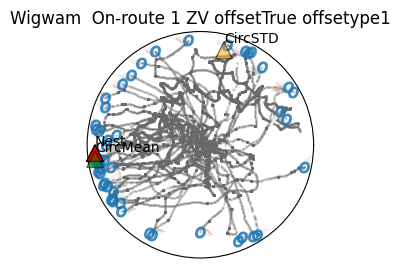

In [73]:
# functionalising and working out best offset


def heading_workingout(df, nest, condition, all=True, seyiornay=False, offset=(False, 180), arrows=-1, offsettype=1):
    # 240425 - using scipy circular stats functions
    # sample df by nest and condition type
    """ Produces polar plot of multiple ant paths per condition.
         Final Heading is highlighted in blue O and beige arrows
         Paths plotted in grey
         x num of triangles drawn to show strategic points such as nest direction
         """
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # 
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    
    # lists to hold final headings (radians or degrees)
    final_headings_list_theta = []    
    final_r_list_theta = []
    # 'setting' vars for plotting
    alphaval_path = 0.15
    alpha_finalp = 0.7
    arrow_frames = arrows
    # set fig size
    fig = plt.figure(figsize=(10, 10)) #10, 10
    ax = fig.add_subplot(321,projection='polar') 

    if offset[0]:
        offsetval = offset[1]
    else:
        offsetval = 0
    """ BEGIN """
    for id in unique_ids:
        # subset df further by trial/ ant ID
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x']) # getting out our cartesian coordinates from the df
        _y =  np.array(usedf['y'])
        #final_xy.append((_x[-1], _y[-1]))
        usedf, r_full = delta_pos(usedf,_x,_y) # change in x, y pos added to df

        if seyiornay== True:
            theta_full = headingdir_seyi(usedf) # Seyi function
        else:
            theta_full, r_full = cart2pola(_x,_y) # Nay function
        theta_full = [0 if maths.isnan(i) else i for i in theta_full] # hide that nan

        # Cornelia - path cutting  between 2 and 29 cm
        x_cut, y_cut = cut_path(r_full, _x, _y)
        theta, r = cart2pola(x_cut, y_cut) # transform to pola coordinates

        finalpoint_theta = theta[-1] # taking the final point in RADIANS

        if offsettype == 1:
            headings_end = [a + offsetval for a in np.rad2deg(theta_full)]#[arrow_frames:]]# theta_full[arrow_frames:] + offsetval
        elif offsettype ==2:
            headings_end = [rel2Nest(a) for a in np.rad2deg(theta_full)]
        elif offsettype ==3:
            headings_end = [(offsetval -a) for a in np.rad2deg(theta_full)]
        elif offsettype ==4:
            headings_end = [(offsetval -a) %360 for a in np.rad2deg(theta_full)]
        
        #headings_end =[]
        #dy, dx = usedf['y'].diff(periods=1), usedf['x'].diff(periods=1)
        #for (x,y) in zip(dx, dy):
        #    head = seyiheading_from_d(y, x, offset=180)
        #    headings_end.append(head)
        #headings_end = seyiheading_from_d(dy, dx, offset=180)
        """angle = np.rad2deg(np.arctan2(dy, dx))
        #need to use modulus % to scale things back to 0 to 360 degrees
        heading = (90-angle) % 360"""
        
        #ax.scatter(theta_full[:arrow_frames], r_full[:arrow_frames], c='dimgray', s=0.7, alpha=alphaval_path)
        
        #ax.quiver(theta[arrow_frames::20], r[arrow_frames::20],
        #          np.sin(np.deg2rad(headings_end[::20])),  
        #          np.cos(np.deg2rad(r_full[arrow_frames::20][0])),
        #          usedf['frame'][arrow_frames::20], 
        #          ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        #print(f"headings_end {headings_end[-5::2]}")
        ax.quiver(theta_full[arrow_frames:],  # x
                  r_full[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax.scatter(theta_full[:], r_full[:], c='dimgray', s=0.7, alpha=alphaval_path)
        
        # too messy with everything as arrows - have last 5 frames as arrows?

        final_headings_list_theta.append(finalpoint_theta) #finalpoint_theta Append to final headings list (once per ant) #finalpoint_degree2theta
        final_r_list_theta.append(r[-1] ) # append to final radius list)

    # For all ants in this condition
    circmean_heading_theta = rayleigh_circmean(final_headings_list_theta)
    # taking the standard deviation of the final headings list
    mean_std_theta = scipy.stats.circstd(final_headings_list_theta)#np.std(final_headings_list_theta)
    print(f" circ mean std  theta {mean_std_theta}")

    # Blue O final heading direction
    scatter_theta = ax.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) # plot the final heading directions
    ax.title.set_text(f'{nest}  {condition} offset{offset[0]} offsetype{offsettype}')
    # x num of arrows

    """
    %% plot tree-to-nest direction in grey
    %homing direction for different releases at WIGWAM nest:
    % homing=-180+55;%off-route 1
    % homing=180-115;%on-route 2
    % homing=180-102;%unfamiliar
    """
    #if nest =='Wigwam':
    #    if condition == "On-route 1 ZV":
    #        tree_dir =
    
    
    add_plot_arrows(ax,(final_r_list_theta, 'blue', "fin theta"),(circmean_heading_theta, 'green', "CircMean"),(mean_std_theta, 'orange', "CircSTD"))

    ax.grid(False)
    plt.xticks([]) 
    plt.yticks([])
    plt.show()

heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(True, 180), arrows=-7)
        

rayleigh directedness res  <class 'numpy.float64'>
 mean heading   : 3.199384445690141
circ mean heading theta 3.199384445690141
 circ mean std  theta 1.3457150942194736


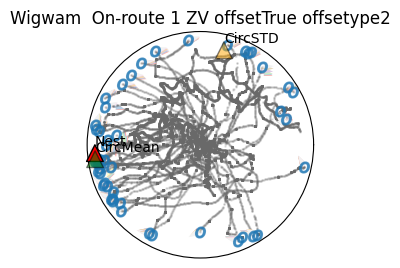

In [74]:
heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(True, 180),seyiornay=False, arrows=-7, offsettype=2)

In [ ]:
# functionalising and working out best offset

def heading_workingout_multi(df, nest, condition, all=True, seyiornay=False, offset=(False, 180), arrows=-1, offsettype=1):
    # 240425 - using scipy circular stats functions
    # sample df by nest and condition type
    """ Produces polar plot of multiple ant paths per condition.
         Final Heading is highlighted in blue O and beige arrows
         Paths plotted in grey
         x num of triangles drawn to show strategic points such as nest direction
         """
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # 
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    
    # lists to hold final headings (radians or degrees)
    final_headings_list_theta = []    
    final_r_list_theta = []
    # 'setting' vars for plotting
    alphaval_path = 0.15
    alpha_finalp = 0.7
    arrow_frames = arrows
    # set fig size
    fig = plt.figure(figsize=(30, 30)) #10, 10
    ax1 = fig.add_subplot(451,projection='polar') 
    ax2 = fig.add_subplot(452,projection='polar') 
    ax3 = fig.add_subplot(453,projection='polar') 
    ax4 = fig.add_subplot(454,projection='polar') 
    ax5 = fig.add_subplot(455,projection='polar') 
    ax6 = fig.add_subplot(456,projection='polar') 
    ax7 = fig.add_subplot(457,projection='polar') 
    ax8 = fig.add_subplot(458,projection='polar') 
    ax9 = fig.add_subplot(459,projection='polar') 
    ax10 = fig.add_subplot(4,5,10,projection='polar') 
    ax11 = fig.add_subplot(4,5,11,projection='polar') 
    ax12 = fig.add_subplot(4,5,12,projection='polar') 
    ax13 = fig.add_subplot(4,5,13,projection='polar') 
    ax14 = fig.add_subplot(4,5,14,projection='polar') 
    ax15 = fig.add_subplot(4,5,15,projection='polar') 
    ax16 = fig.add_subplot(4,5,16,projection='polar') 
    ax17 = fig.add_subplot(4,5,17,projection='polar') 
    ax18 = fig.add_subplot(4,5,18,projection='polar') 
    ax19 = fig.add_subplot(4,5,19,projection='polar') 
    ax20 = fig.add_subplot(4,5,20,projection='polar') 

    if offset[0]:
        offsetval = offset[1]
    else:
        offsetval = 0
    """ BEGIN """
    for id in unique_ids:
        # subset df further by trial/ ant ID
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x']) # getting out our cartesian coordinates from the df
        _y =  np.array(usedf['y'])
        step = 10
        #final_xy.append((_x[-1], _y[-1]))
        usedf, r_full_nayog = delta_pos(usedf,_x,_y) # change in x, y pos added to df

        #if seyiornay== True:
        theta_full_seyi = headingdir_seyi(usedf) # Seyi function
        theta_full_seyi = [0 if maths.isnan(i) else i for i in theta_full_seyi] 
        #else:
        theta_full_nay, r_full_nay = cart2pola(_x,_y) # Nay function
        theta_full_nay = [0 if maths.isnan(i) else i for i in theta_full_nay] # hide that nan

        # Cornelia - path cutting  between 2 and 29 cm
        x_cut_cornelia, y_cut_cornelia = cut_path(r_full_nay, _x, _y)
        theta_cornelia, r_cornelia = cart2pola(x_cut_cornelia, y_cut_cornelia) # transform to pola coordinates

        finalpoint_theta = theta_cornelia[-1] # taking the final point in RADIANS

        # No offset
        headings_end_nooffset = [offsetval for a in np.rad2deg(theta_full_nay)]
        # if offsettype == 1:
        headings_end_plusoffset_nay = [a + offsetval for a in np.rad2deg(theta_full_nay)]
        headings_end_plusoffset_seyi = [a + offsetval for a in np.rad2deg(theta_full_seyi)]#[arrow_frames:]]# theta_full[arrow_frames:] + offsetval
        headings_end_plusoffset_cornelia = [a + offsetval for a in np.rad2deg(theta_cornelia)]
        # elif offsettype ==2:
        headings_end_rel2nest_nay = [rel2Nest(a) for a in np.rad2deg(theta_full_nay)]
        headings_end_rel2nest_cornelia = [rel2Nest(a) for a in np.rad2deg(theta_cornelia)]
        headings_end_rel2nest_seyi = [rel2Nest(a) for a in np.rad2deg(theta_full_seyi)]
        #elif offsettype ==3:
        headings_end_minusoffset_nay = [(offsetval -a) for a in np.rad2deg(theta_full_nay)]
        headings_end_minusoffset_seyi = [(offsetval -a) for a in np.rad2deg(theta_full_seyi)]
        headings_end_minusoffset_cornelia = [(offsetval -a) for a in np.rad2deg(theta_cornelia)]
        #elif offsettype ==4:
        headings_end_offsetminus_nay = [(a- offsetval) %360 for a in np.rad2deg(theta_full_nay)]
        headings_end_offsetminus_seyi = [(a- offsetval) %360 for a in np.rad2deg(theta_full_seyi)]
        headings_end_offsetminus_cornelia = [(a- offsetval) %360 for a in np.rad2deg(theta_cornelia)]
        
        headingsend_lst_seyi =[]
        dy, dx = usedf['y'].diff(periods=1), usedf['x'].diff(periods=1)
        for (x,y) in zip(dx, dy):
            head = seyiheading_from_d(y, x, offset=180)
            headingsend_lst_seyi.append(head)
            
        # Nay No Offset
        ax1.quiver(theta_full_nay[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_nooffset[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full_nay[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax1.scatter(theta_full_nay[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax1.title.set_text('nay no offset')
        
        
        # Nay  # plus offset
        ax2.quiver(theta_full_nay[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_plusoffset_nay[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full_nay[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax2.scatter(theta_full_nay[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax2.title.set_text('nay plus offset')
        # Nay # rel2nest
        ax3.quiver(theta_full_nay[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_rel2nest_nay[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full_nay[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax3.scatter(theta_full_nay[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax3.title.set_text('nay rel2nest')
         # Nay # mius offset
        ax4.quiver(theta_full_nay[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_minusoffset_nay[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full_nay[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax4.scatter(theta_full_nay[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax4.title.set_text('nay minus offset')
        # Nay # offset minus
        ax5.quiver(theta_full_nay[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_offsetminus_nay[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full_nay[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax5.scatter(theta_full_nay[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax5.title.set_text('nay offset minus')

        
        # Seyi # plus offset
        ax6.quiver(_x[arrow_frames:],  # x
                  _y[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_plusoffset_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_plusoffset_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax6.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax6.title.set_text('seyi plus offset')
        # Seyi   # rel2nest
        ax7.quiver(_x[arrow_frames:],  # x
                  _y[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_rel2nest_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_rel2nest_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax7.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax7.title.set_text('seyi rel2nest')
        # Seyi  # mius offset
        ax8.quiver(_x[arrow_frames:],  # x
                  _y[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_minusoffset_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_minusoffset_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax8.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax8.title.set_text('seyi minus offset')
         # Seyi  # offset minus
        ax9.quiver(_x[arrow_frames:],  # x
                  _y[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_offsetminus_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_offsetminus_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax9.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax9.title.set_text('seyi offset minus')
         # seyi fuller 1 # offset minus
        ax10.quiver(_x[arrow_frames:],  # x
                  _y[arrow_frames:],      # y
                  np.sin(np.deg2rad(headingsend_lst_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headingsend_lst_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax10.scatter(headingsend_lst_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax10.title.set_text('fuller seyi 1')
        # Seyi / with nayplot # plus offset
        ax11.quiver(theta_full_seyi[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_plusoffset_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_plusoffset_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax11.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax11.title.set_text('seyi plus offset (nayplotting)')
         # Seyi w/ nay plotting # rel2nest
        ax12.quiver(theta_full_seyi[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_rel2nest_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_rel2nest_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax12.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax12.title.set_text('seyi rel2nest (nayplotting)')
        
        # Seyi w/ nay plotting # mius offset
        ax13.quiver(theta_full_seyi[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_minusoffset_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_minusoffset_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax13.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax13.title.set_text('seyi minus offset (nayplotting)') 
       
        # Seyi with nay plotting # offset minus
        ax14.quiver(theta_full_seyi[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_offsetminus_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headings_end_offsetminus_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax14.scatter(theta_full_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax14.title.set_text('seyi offset minus (nayplotting)')
       
        # seyi fuller 1 nay plotting  # offset minus
        ax15.quiver(headingsend_lst_seyi[arrow_frames:],  # x
                  r_full_nay[arrow_frames:],      # y
                  np.sin(np.deg2rad(headingsend_lst_seyi[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(headingsend_lst_seyi[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax15.scatter(headingsend_lst_seyi[:], r_full_nay[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax15.title.set_text('fuller seyi 1 (nayplotting)')

        
        # Cornelia # plus offset
        ax16.quiver(theta_cornelia[arrow_frames:],  # x
                  r_cornelia[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_plusoffset_cornelia[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_cornelia[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax16.scatter(theta_cornelia[:], r_cornelia[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax16.title.set_text('cornelia plus offset')
        # Cornelia  rel2nest
        ax17.quiver(theta_cornelia[arrow_frames:],  # x
                  r_cornelia[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_rel2nest_cornelia[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_cornelia[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax17.scatter(theta_cornelia[:], r_cornelia[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax17.title.set_text('cornelia rel2nest')
        # cornelia # mius offset
        ax18.quiver(theta_cornelia[arrow_frames:],  # x
                  r_cornelia[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_minusoffset_cornelia[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_cornelia[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax18.scatter(theta_cornelia[:], r_cornelia[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax18.title.set_text('cornelia minus offset')
        # Cornelia # offset minus
        ax19.quiver(theta_cornelia[arrow_frames:],  # x
                  r_cornelia[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end_offsetminus_cornelia[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_cornelia[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax19.scatter(theta_cornelia[:], r_cornelia[:], c='dimgray', s=0.7, alpha=alphaval_path)
        ax19.title.set_text('cornelia offset minus')
        
        # checking closer to seyi code
        dxsseyi, dysseyi = np.array(usedf['dx']), np.array(usedf['dy'])
        thetaseyi = []
        for (dx, dy) in zip(dxsseyi, dysseyi):
                heading = seyiheading_from_d(dx, dy)
                thetaseyi.append(heading+offsetval)
        
        #thetaseyi = theta[::step]
        
        
        ax20.quiver(usedf['x'][::step],  # x
                   usedf['y'][::step],      # y
                   np.sin(np.deg2rad(thetaseyi[::step])),    # U [0]
                   np.cos(np.deg2rad(thetaseyi[::step])),  # V
                   usedf['frame'][::step],   # C
                   ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax20.title.set_text('seyi clsr 2 code')
        # too messy with everything as arrows - have last 5 frames as arrows?

        final_headings_list_theta.append(finalpoint_theta) #finalpoint_theta Append to final headings list (once per ant) #finalpoint_degree2theta
        final_r_list_theta.append(r_cornelia[-1] ) # append to final radius list)

    # For all ants in this condition
    circmean_heading_theta = rayleigh_circmean(final_headings_list_theta)
    # taking the standard deviation of the final headings list
    mean_std_theta = scipy.stats.circstd(final_headings_list_theta)#np.std(final_headings_list_theta)
    print(f" circ mean std  theta {mean_std_theta}")

    # Blue O final heading direction
    ax1.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) # plot the final heading directions
    ax2.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax3.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax4.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax5.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax6.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax7.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax8.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax9.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax10.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax11.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax12.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) 
    ax13.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax14.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax15.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax16.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax17.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax18.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax19.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)
    ax20.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60)

    fig.suptitle(f'{nest}  {condition} offset{offset[0]} offsetype{offsettype}')
    
    # x num of arrows

    """
    %% plot tree-to-nest direction in grey
    %homing direction for different releases at WIGWAM nest:
    % homing=-180+55;%off-route 1
    % homing=180-115;%on-route 2
    % homing=180-102;%unfamiliar
    """
    #if nest =='Wigwam':
    #    if condition == "On-route 1 ZV":
    #        tree_dir =
    
    
    add_plot_arrows(ax,(final_r_list_theta, 'blue', "fin theta"),(circmean_heading_theta, 'green', "CircMean"),(mean_std_theta, 'orange', "CircSTD"))

    #ax.grid(False)
    plt.xticks([]) 
    plt.yticks([])
    plt.show()

heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(True, 180), arrows=-30)
        

In [ ]:
heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(True, 180), arrows=-7, offsettype=3)

In [ ]:
heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(True, 180), arrows=-7, offsettype=4)

In [ ]:
heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(False, 180), arrows=-7)

In [ ]:
heading_workingout(antTrackDF, 'Wigwam', "Off-route 1 ZV", offset=(False, 180), arrows=-30)

In [ ]:
heading_workingout(antTrackDF, 'Wigwam', "Off-route 1 ZV", offset=(True, 180), arrows=-30)

In [ ]:
heading_workingout(antTrackDF, 'Wigwam', "On-route 2 ZV")

## Final

In [ ]:
heading_directions(antTrackDF, 'NewNest', "Off-route 1 ZV")

In [ ]:
# final heading diretion
# heading direction at multiple points following path exact.


def heading_directions(df, nest, condition, all=True):

    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    final_headings_list = []
    final_r_list = []


    for id in unique_ids:
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x'])
        _y =  np.array(usedf['y'])

        theta, r = cart2pola(_x,_y) # need x and y in array. converts to polar coordinates
        #degrees = theta*180/np.pi # converts from radians to degrees
        final_heading = theta[-1]#degrees[-1] # last heading = final heading dir

        final_headings_list.append(final_heading) #final_heading_rel2Nest
        final_r_list.append(r[-1])

    mean_heading = np.mean(final_headings_list)
    
    mean_std = np.std(final_headings_list)
    print(f"mean std {mean_std}")
    median_heading = np.median(final_headings_list)
    
    max_r = max(final_r_list)
    print(f"mean heading : {mean_heading}, max r : {max_r}")
    
    print(f"final heading list:{final_headings_list}")
    # plotting the final heading directions
    print(len(final_headings_list), len(range(len(final_headings_list) -1)))
    fig = plt.figure(figsize=(10, 10)) #10, 10
    data_point = -30
    print(f"final_r_list[data_point] {final_r_list[data_point]}")
    ax = fig.add_subplot(projection='polar') # set to polar plot
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("W") # set the nest (0) to the west pos
    scatter2 = ax.scatter(final_headings_list, final_r_list, alpha=0.4, s= 16, cmap="gist_rainbow") # plot the final heading directions

    angle_90 = np.radians(90)
    angle_180 = np.radians(180)
    x_90, y_90 = max_r * np.cos(angle_90), max_r*np.sin(angle_90)
    x_180, y_180 = max_r * np.cos(angle_180), max_r*np.sin(angle_180)

    ax.annotate('', xy=(x_90, y_90), xytext=(0,0),arrowprops=dict(facecolor="orchid", shrink=0.05, alpha=0.6)) # arrow to check working of arrow

    ax.grid(True)

    fig.suptitle(f"{np.unique(newdf['Nest'])} {np.unique(newdf['Condition'])} \n Mean Heading : {mean_heading} \n Median Heading : {median_heading}")
    plt.show()

    print(f"Final heading list: {final_headings_list}")
    print(f"Final mean heading list: {mean_heading}, median heading {median_heading}")


# 'Wigwam', "Off-route 1 ZV"
heading_directions(antTrackDF, 'Wigwam', "On-route 1 ZV")

# Wigwam

Wigwam codnitions:  
 'Off-route 1 ZV'
 'On-route 1 ZV' 
 'On-route 2 ZV'
 'Unfamiliar FV' 
 'Unfamiliar ZV'

         Date   ID  frame          x           y    Nest       Condition  \
49761  Jul-18  270      0  26.058557   -3.232724  Wigwam  Off-route 1 ZV   
49762  Jul-18  270      1  26.027184   -3.237456  Wigwam  Off-route 1 ZV   
49763  Jul-18  270      2  26.043277   -3.238197  Wigwam  Off-route 1 ZV   
49764  Jul-18  270      3  26.013301   -3.241354  Wigwam  Off-route 1 ZV   
49765  Jul-18  270      4  26.014456   -3.245170  Wigwam  Off-route 1 ZV   
...       ...  ...    ...        ...         ...     ...             ...   
50807  Jul-18  270   1055 -80.262221 -230.293323  Wigwam  Off-route 1 ZV   
50808  Jul-18  270   1056 -80.166644 -230.211508  Wigwam  Off-route 1 ZV   
50809  Jul-18  270   1057 -81.614957 -230.676072  Wigwam  Off-route 1 ZV   
50810  Jul-18  270   1058 -83.274157 -231.077015  Wigwam  Off-route 1 ZV   
50811  Jul-18  270   1060 -84.868862 -231.781218  Wigwam  Off-route 1 ZV   

       delta_distance(pix)  speed(px/s)   accumdist  
49761                  NaN       

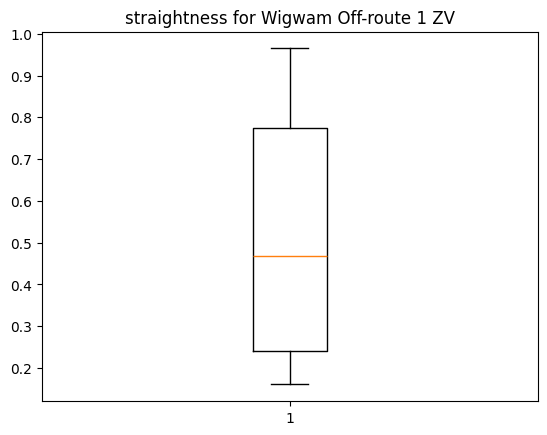

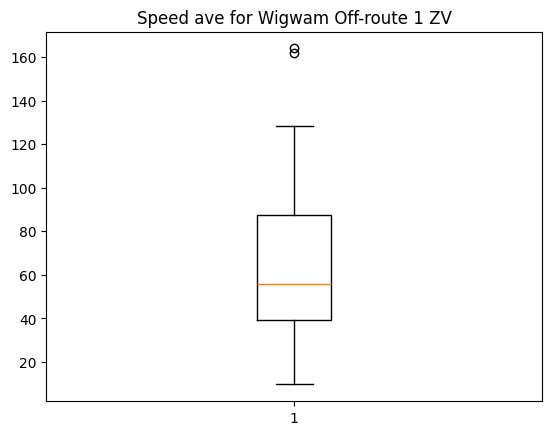

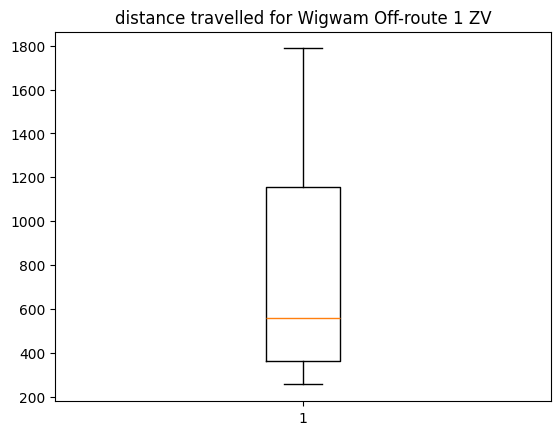

In [298]:
straightness = stats_condition(df=antTrackDF, nest='Wigwam', condition='Off-route 1 ZV', all=False)

In [299]:
np.mean(straightness)

0.5279878205630527

         Date   ID  frame           x         y    Nest      Condition  \
36620  Jul-18  283      0   -8.031217  0.837603  Wigwam  On-route 1 ZV   
36621  Jul-18  283      1   -8.416378 -0.421767  Wigwam  On-route 1 ZV   
36622  Jul-18  283      2   -8.630301 -0.763612  Wigwam  On-route 1 ZV   
36623  Jul-18  283      3   -8.406953 -1.172378  Wigwam  On-route 1 ZV   
36624  Jul-18  283      4   -8.552935 -1.929263  Wigwam  On-route 1 ZV   
...       ...  ...    ...         ...       ...     ...            ...   
37464  Jul-18  283    844 -255.403392 -2.240409  Wigwam  On-route 1 ZV   
37465  Jul-18  283    845 -256.482319 -2.525378  Wigwam  On-route 1 ZV   
37466  Jul-18  283    846 -257.637115 -2.579874  Wigwam  On-route 1 ZV   
37467  Jul-18  283    847 -258.912045 -2.301940  Wigwam  On-route 1 ZV   
37468  Jul-18  283    848 -259.774088 -1.416818  Wigwam  On-route 1 ZV   

       delta_distance(pix)  speed(px/s)   accumdist  
36620                  NaN          NaN         NaN  
366

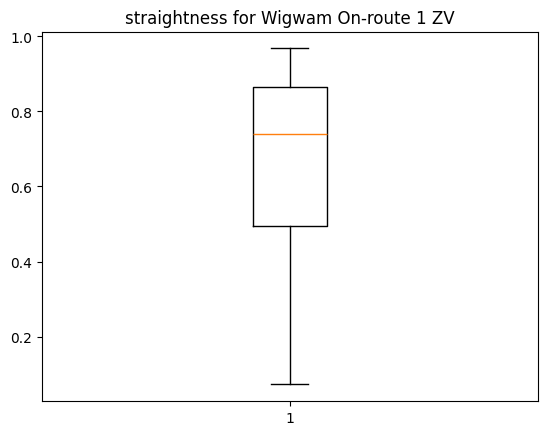

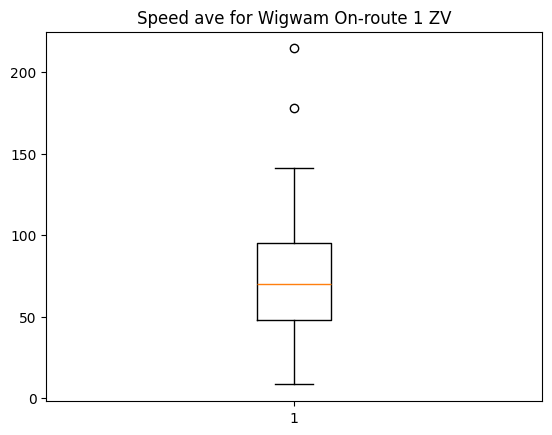

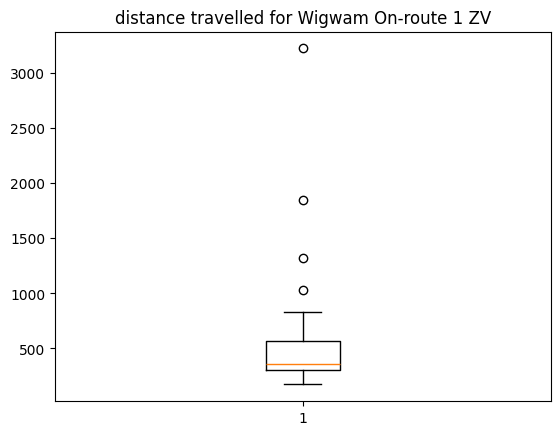

In [300]:
straightness = stats_condition(df=antTrackDF, nest='Wigwam', condition='On-route 1 ZV', all=False)

In [301]:
np.mean(straightness)

0.6824510087592658

         Date   ID  frame           x           y    Nest      Condition  \
11680  Jul-18  298      0    1.589427   10.794481  Wigwam  On-route 2 ZV   
11681  Jul-18  298      1    1.592638   10.801772  Wigwam  On-route 2 ZV   
11682  Jul-18  298      2    1.596779   10.805251  Wigwam  On-route 2 ZV   
11683  Jul-18  298      3    1.638789   10.808011  Wigwam  On-route 2 ZV   
11684  Jul-18  298      4    1.178386   10.705158  Wigwam  On-route 2 ZV   
...       ...  ...    ...         ...         ...     ...            ...   
12841  Jul-18  298   1161  233.676324  134.109152  Wigwam  On-route 2 ZV   
12842  Jul-18  298   1162  234.229831  135.150934  Wigwam  On-route 2 ZV   
12843  Jul-18  298   1163  235.091522  136.355996  Wigwam  On-route 2 ZV   
12844  Jul-18  298   1164  235.467686  137.822633  Wigwam  On-route 2 ZV   
12845  Jul-18  298   1165  235.598820  138.824024  Wigwam  On-route 2 ZV   

       delta_distance(pix)  speed(px/s)   accumdist  
11680                  NaN       

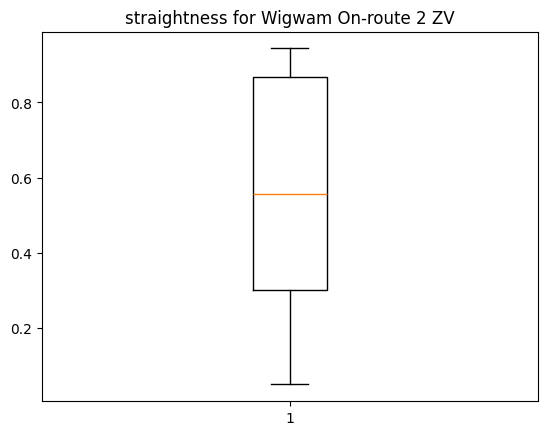

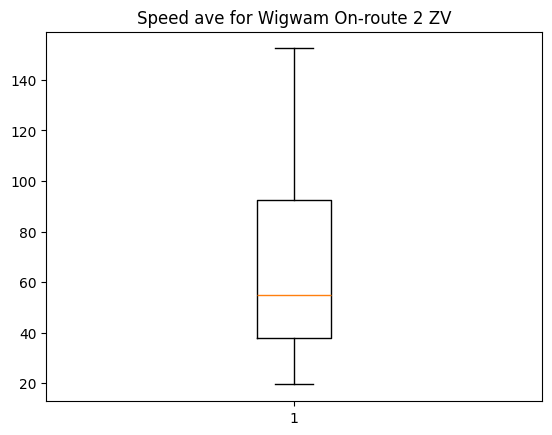

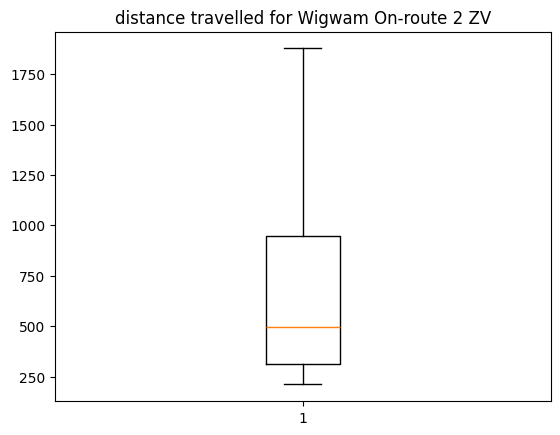

In [302]:
straightness = stats_condition(df=antTrackDF, nest='Wigwam', condition='On-route 2 ZV', all=False)

In [303]:
np.mean(straightness)

0.5686620319066814

          Date   ID  frame           x          y    Nest      Condition  \
146445  Aug-09  366      0   -9.614913 -22.638443  Wigwam  Unfamiliar FV   
146446  Aug-09  366      1  -10.116773 -22.560443  Wigwam  Unfamiliar FV   
146447  Aug-09  366      2  -11.030513 -23.032448  Wigwam  Unfamiliar FV   
146448  Aug-09  366      3  -12.227820 -24.114467  Wigwam  Unfamiliar FV   
146449  Aug-09  366      4  -13.014467 -26.227568  Wigwam  Unfamiliar FV   
...        ...  ...    ...         ...        ...     ...            ...   
146638  Aug-09  366    310 -262.069699 -53.235946  Wigwam  Unfamiliar FV   
146639  Aug-09  366    311 -263.573905 -53.594650  Wigwam  Unfamiliar FV   
146640  Aug-09  366    312 -264.437080 -54.183212  Wigwam  Unfamiliar FV   
146641  Aug-09  366    313 -265.760681 -54.602441  Wigwam  Unfamiliar FV   
146642  Aug-09  366    314 -267.603927 -55.044137  Wigwam  Unfamiliar FV   

        delta_distance(pix)  speed(px/s)   accumdist  
146445                  NaN     

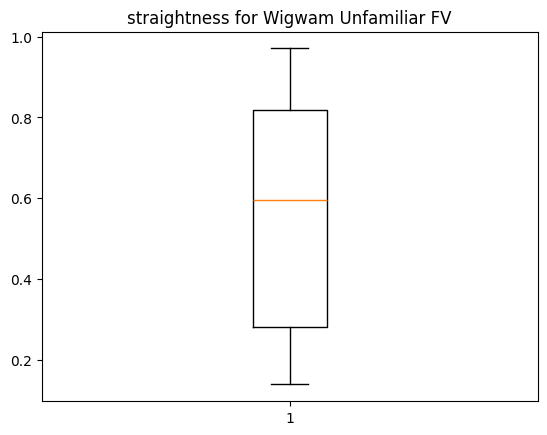

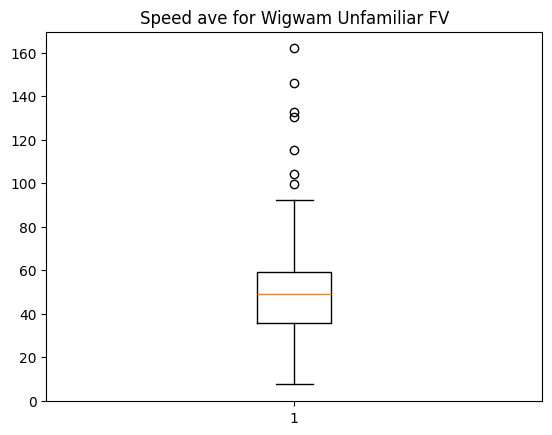

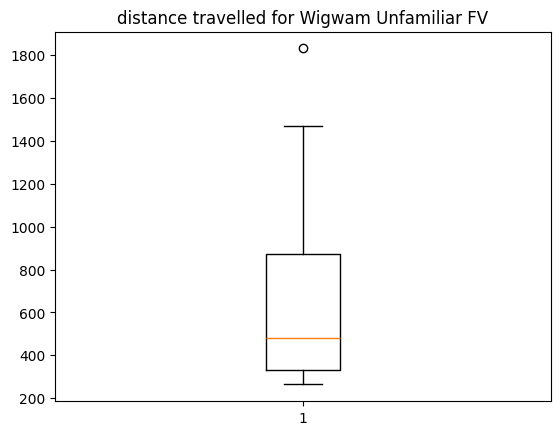

In [304]:
straightness = stats_condition(df=antTrackDF, nest='Wigwam', condition='Unfamiliar FV', all=False)

In [305]:
np.mean(straightness)

0.5669002277704968

         Date   ID  frame           x           y    Nest      Condition  \
43722  Jul-18  310      0    1.857500   -5.073659  Wigwam  Unfamiliar ZV   
43723  Jul-18  310      1    2.668424   -4.630383  Wigwam  Unfamiliar ZV   
43724  Jul-18  310      2    3.343125   -4.416704  Wigwam  Unfamiliar ZV   
43725  Jul-18  310      3    4.408848   -3.673271  Wigwam  Unfamiliar ZV   
43726  Jul-18  310      4    5.107472   -2.470958  Wigwam  Unfamiliar ZV   
...       ...  ...    ...         ...         ...     ...            ...   
45721  Jul-18  310   2007 -172.574726  230.150688  Wigwam  Unfamiliar ZV   
45722  Jul-18  310   2008 -172.147295  230.340210  Wigwam  Unfamiliar ZV   
45723  Jul-18  310   2009 -172.946929  230.705085  Wigwam  Unfamiliar ZV   
45724  Jul-18  310   2010 -172.913463  230.677924  Wigwam  Unfamiliar ZV   
45725  Jul-18  310   2011 -172.766958  230.668748  Wigwam  Unfamiliar ZV   

       delta_distance(pix)  speed(px/s)   accumdist  
43722                  NaN       

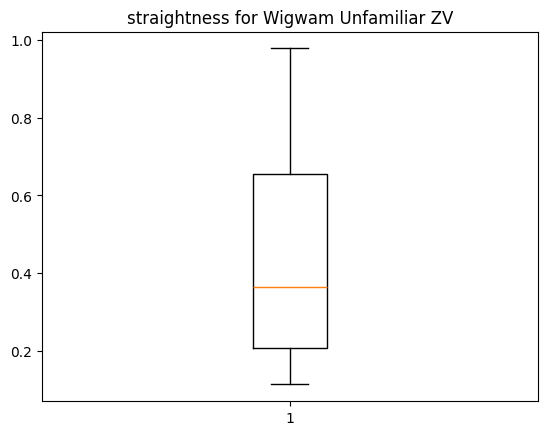

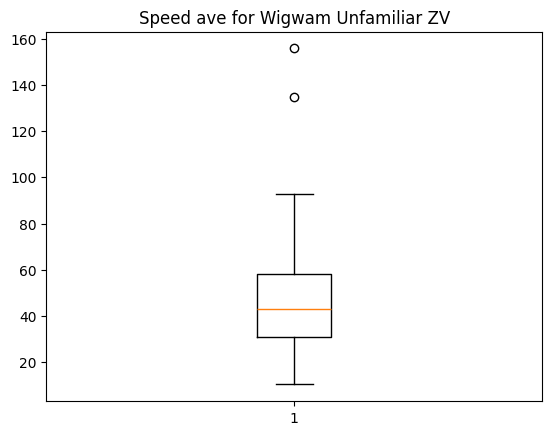

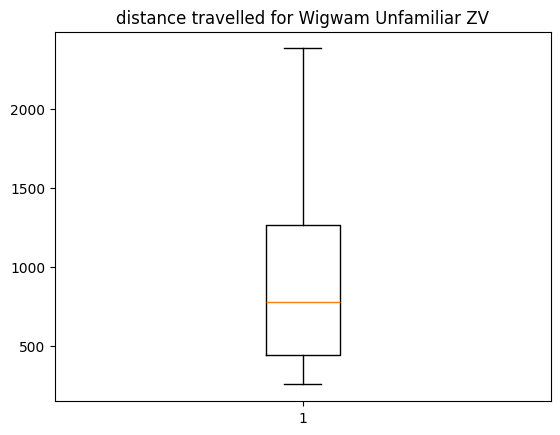

In [306]:
straightness = stats_condition(df=antTrackDF, nest='Wigwam', condition='Unfamiliar ZV', all=False)

In [307]:
np.mean(straightness)

0.43534278764002743

# NewNest

NewNest Conditions:
'Eye-capped off-route 1' 
'Eye-capped on-route 1' 
'Minus 3m ZV'
 'Plus 3m ZV'
  'Route 0m ZV'
 'Off-route 1 ZV'
 'On-route 1 ZV' 
 'On-route 1B ZV'
 'On-route 2 ZV'
 'Unfamiliar FV' 
 'Unfamiliar ZV'
 'Unfamiliar ZV 2' 
 'Unfamiliar ZV 3'

           Date   ID  frame           x          y     Nest  \
2328158  Sep-23  192      0   -7.874331  -5.678055  NewNest   
2328159  Sep-23  192      1   -7.179074  -5.738707  NewNest   
2328160  Sep-23  192      2   -6.876221  -5.762784  NewNest   
2328161  Sep-23  192      3   -6.972239  -5.692476  NewNest   
2328162  Sep-23  192      4   -6.971978  -5.744445  NewNest   
...         ...  ...    ...         ...        ...      ...   
2328824  Sep-23  192    670  282.664422  35.611265  NewNest   
2328825  Sep-23  192    671  283.220257  34.944740  NewNest   
2328826  Sep-23  192    677  285.552246  31.396012  NewNest   
2328827  Sep-23  192    678  285.628006  31.217196  NewNest   
2328828  Sep-23  192    679  286.015017  31.055530  NewNest   

                      Condition  delta_distance(pix)  speed(px/s)   accumdist  
2328158  Eye-capped off-route 1                  NaN          NaN         NaN  
2328159  Eye-capped off-route 1             0.697898    69.789787    0.697898  
232

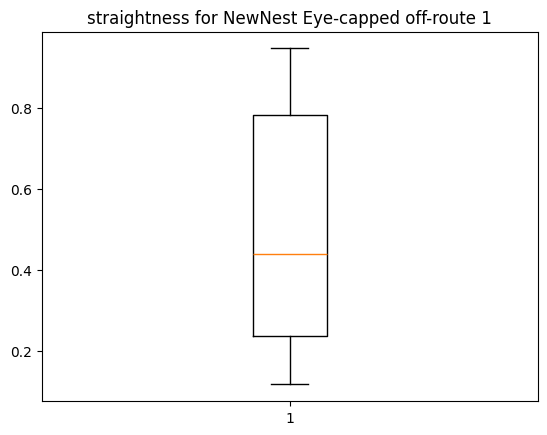

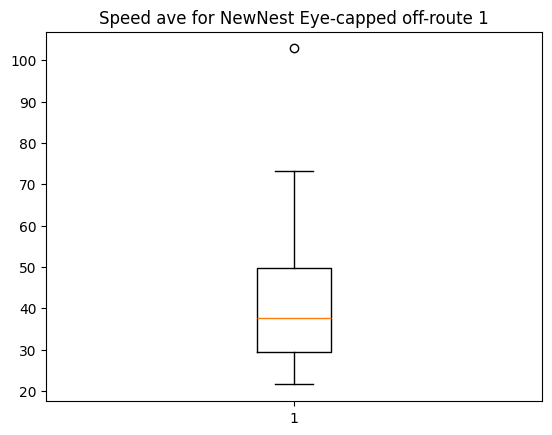

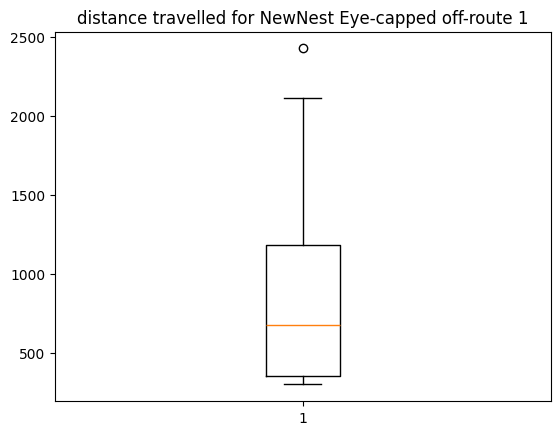

In [308]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Eye-capped off-route 1', all=False)

In [309]:
np.mean(straightness) 

0.5015459792675407

           Date   ID  frame           x          y     Nest  \
2677329  Sep-26  270      0    5.588077   4.495287  NewNest   
2677330  Sep-26  270      1    5.604740   4.423241  NewNest   
2677331  Sep-26  270      2    5.614111   4.437214  NewNest   
2677332  Sep-26  270      3    5.461720   4.493279  NewNest   
2677333  Sep-26  270      4    5.412297   4.486641  NewNest   
...         ...  ...    ...         ...        ...      ...   
2679894  Sep-26  270   2588 -273.320443 -70.029834  NewNest   
2679895  Sep-26  270   2589 -274.045788 -70.093972  NewNest   
2679896  Sep-26  270   2595 -276.605779 -70.119909  NewNest   
2679897  Sep-26  270   2597 -277.841649 -70.079923  NewNest   
2679898  Sep-26  270   2598 -279.352176 -70.203375  NewNest   

                     Condition  delta_distance(pix)  speed(px/s)   accumdist  
2677329  Eye-capped on-route 1                  NaN          NaN         NaN  
2677330  Eye-capped on-route 1             0.073948     7.394770    0.073948  
267733

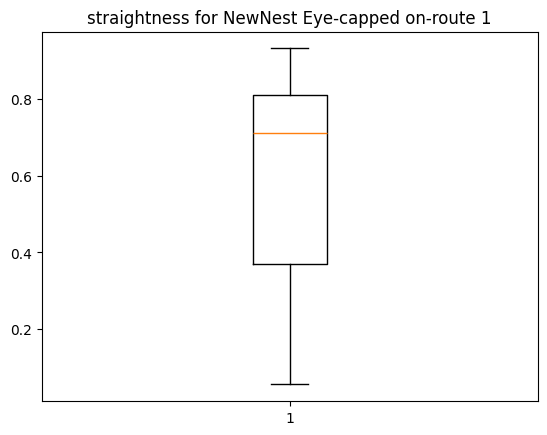

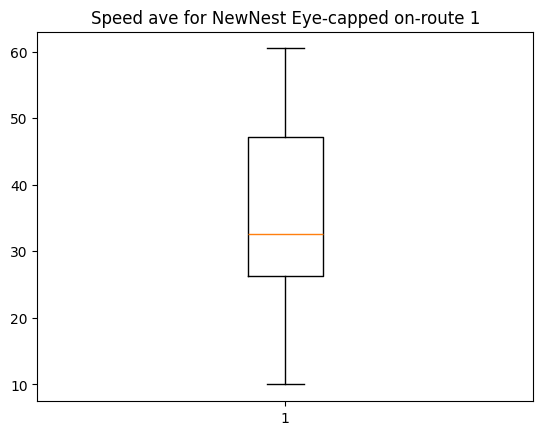

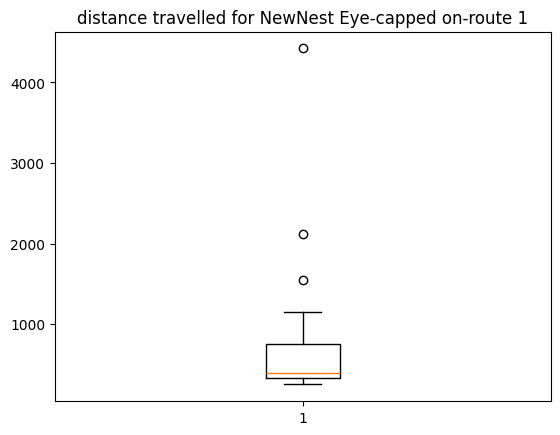

In [310]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Eye-capped on-route 1', all=False)

In [311]:
np.mean(straightness)

0.58457947346268

           Date   ID  frame           x          y     Nest    Condition  \
2139052  Sep-20  108      0    2.465142  -8.808469  NewNest  Minus 3m ZV   
2139053  Sep-20  108      1    2.466109  -8.805917  NewNest  Minus 3m ZV   
2139054  Sep-20  108      2    2.469133  -8.808904  NewNest  Minus 3m ZV   
2139055  Sep-20  108      3    2.474684  -8.809905  NewNest  Minus 3m ZV   
2139056  Sep-20  108      4    2.467686  -8.808331  NewNest  Minus 3m ZV   
...         ...  ...    ...         ...        ...      ...          ...   
2139645  Sep-20  108    609  289.571954  20.402527  NewNest  Minus 3m ZV   
2139646  Sep-20  108    610  290.385733  20.741701  NewNest  Minus 3m ZV   
2139647  Sep-20  108    611  291.764187  21.222564  NewNest  Minus 3m ZV   
2139648  Sep-20  108    612  292.472383  22.174071  NewNest  Minus 3m ZV   
2139649  Sep-20  108    613  293.126386  22.837396  NewNest  Minus 3m ZV   

         delta_distance(pix)  speed(px/s)   accumdist  
2139052                  NaN   

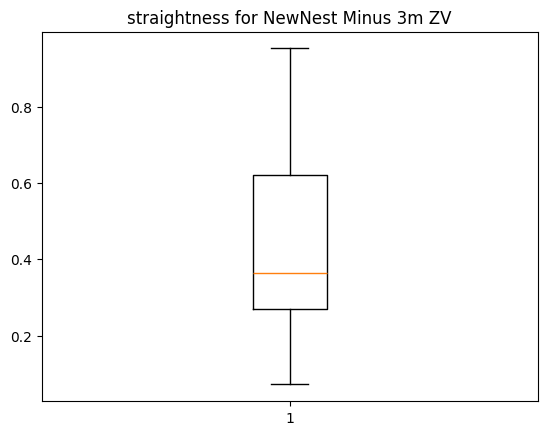

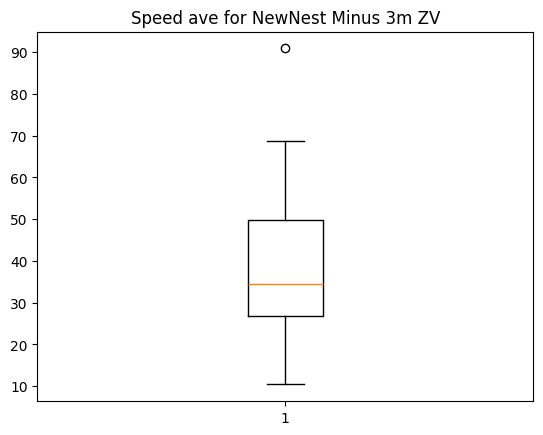

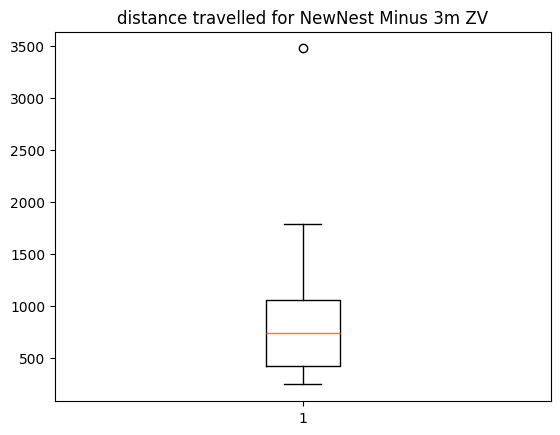

In [312]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Minus 3m ZV', all=False)

In [313]:
np.mean(straightness)

0.46210181676685574

           Date   ID  frame           x          y     Nest   Condition  \
2168614  Sep-20  116      0  -21.446921 -11.719602  NewNest  Plus 3m ZV   
2168615  Sep-20  116      1  -21.360380 -11.576465  NewNest  Plus 3m ZV   
2168616  Sep-20  116      2  -21.308354 -11.519232  NewNest  Plus 3m ZV   
2168617  Sep-20  116      3  -21.280300 -11.462662  NewNest  Plus 3m ZV   
2168618  Sep-20  116      4  -21.285443 -11.461323  NewNest  Plus 3m ZV   
...         ...  ...    ...         ...        ...      ...         ...   
2172003  Sep-20  116   3394  265.759117 -74.070370  NewNest  Plus 3m ZV   
2172004  Sep-20  116   3395  265.846068 -74.079713  NewNest  Plus 3m ZV   
2172005  Sep-20  116   3396  265.916951 -73.961338  NewNest  Plus 3m ZV   
2172006  Sep-20  116   3397  265.935755 -73.968887  NewNest  Plus 3m ZV   
2172007  Sep-20  116   3398  265.868212 -73.924699  NewNest  Plus 3m ZV   

         delta_distance(pix)  speed(px/s)    accumdist  
2168614                  NaN          NaN 

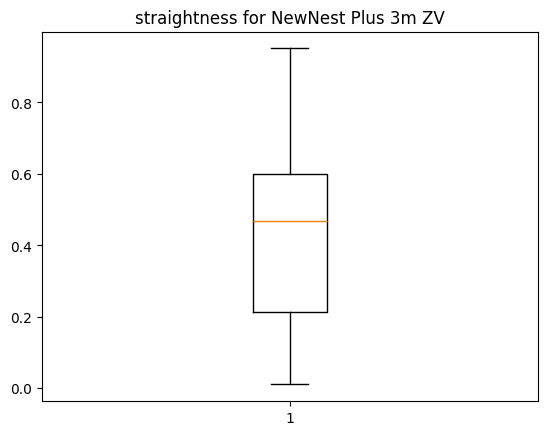

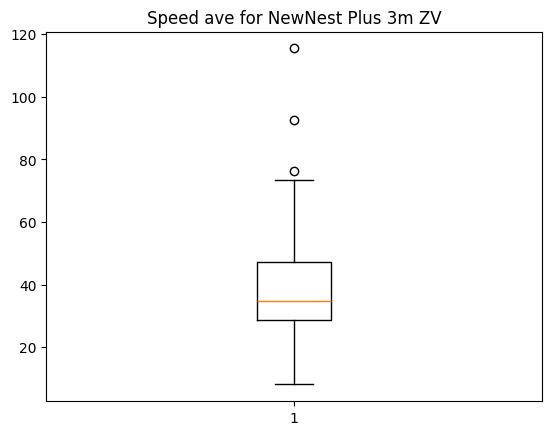

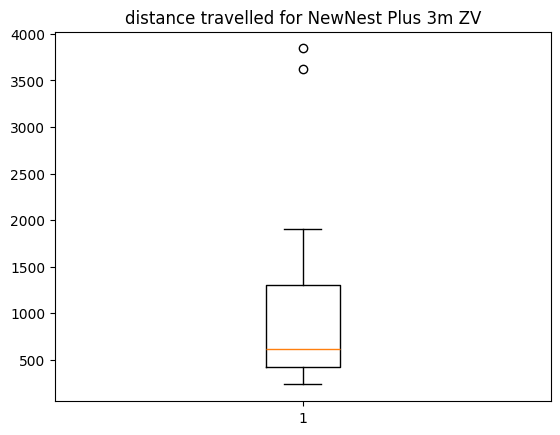

In [314]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Plus 3m ZV', all=False)

In [315]:
np.mean(straightness)

0.454642666212715

           Date   ID  frame           x           y     Nest    Condition  \
2180468  Sep-20  112      0   12.708527   -9.708811  NewNest  Route 0m ZV   
2180469  Sep-20  112      1   12.694151   -9.714172  NewNest  Route 0m ZV   
2180470  Sep-20  112      2   12.589538   -9.677218  NewNest  Route 0m ZV   
2180471  Sep-20  112      3   12.590051   -9.675309  NewNest  Route 0m ZV   
2180472  Sep-20  112      4   12.766909   -9.772462  NewNest  Route 0m ZV   
...         ...  ...    ...         ...         ...      ...          ...   
2185667  Sep-20  112   5199  130.101059  232.196370  NewNest  Route 0m ZV   
2185668  Sep-20  112   5200  130.009489  232.009538  NewNest  Route 0m ZV   
2185669  Sep-20  112   5201  130.028972  232.167786  NewNest  Route 0m ZV   
2185670  Sep-20  112   5202  130.066493  232.037608  NewNest  Route 0m ZV   
2185671  Sep-20  112   5203  130.073882  231.907770  NewNest  Route 0m ZV   

         delta_distance(pix)  speed(px/s)   accumdist  
2180468            

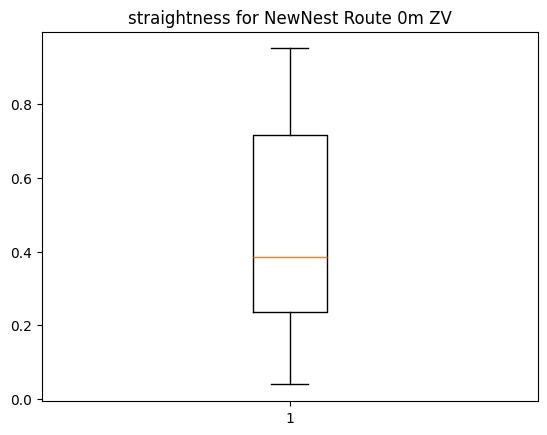

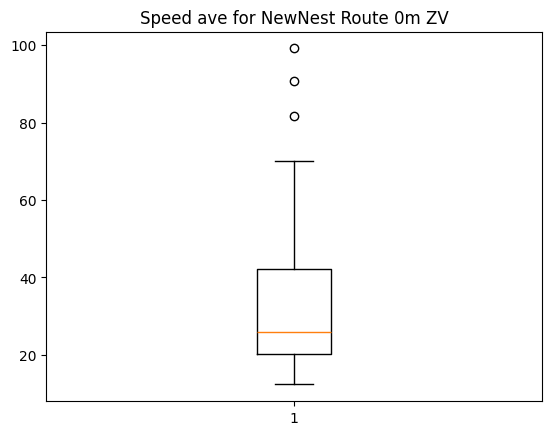

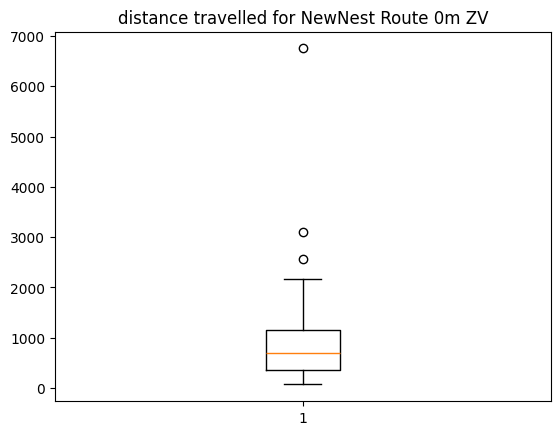

In [316]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Route 0m ZV', all=False)

In [317]:
np.mean(straightness)

0.45381028776392707

          Date   ID  frame           x         y     Nest       Condition  \
519306  Aug-21  561      0    9.136518 -2.818835  NewNest  Off-route 1 ZV   
519307  Aug-21  561      1    9.182885 -2.805765  NewNest  Off-route 1 ZV   
519308  Aug-21  561      2    9.191697 -2.636927  NewNest  Off-route 1 ZV   
519309  Aug-21  561      3    9.230887 -2.650137  NewNest  Off-route 1 ZV   
519310  Aug-21  561      4    9.196637 -2.753849  NewNest  Off-route 1 ZV   
...        ...  ...    ...         ...       ...      ...             ...   
521548  Aug-21  561   2296 -258.810138 -2.638484  NewNest  Off-route 1 ZV   
521549  Aug-21  561   2318 -270.499233  2.574145  NewNest  Off-route 1 ZV   
521550  Aug-21  561   2319 -270.467947  2.823613  NewNest  Off-route 1 ZV   
521551  Aug-21  561   2320 -270.557397  2.973074  NewNest  Off-route 1 ZV   
521552  Aug-21  561   2321 -270.464532  2.981080  NewNest  Off-route 1 ZV   

        delta_distance(pix)  speed(px/s)   accumdist  
519306              

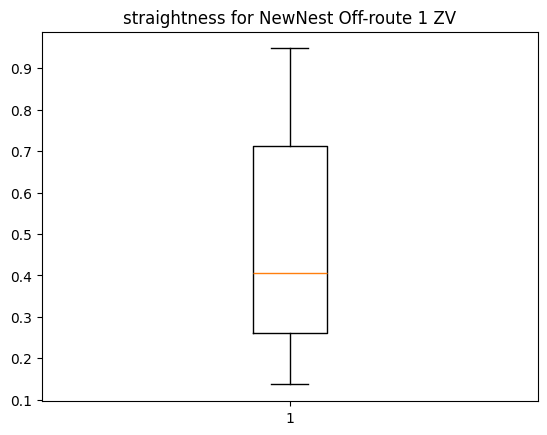

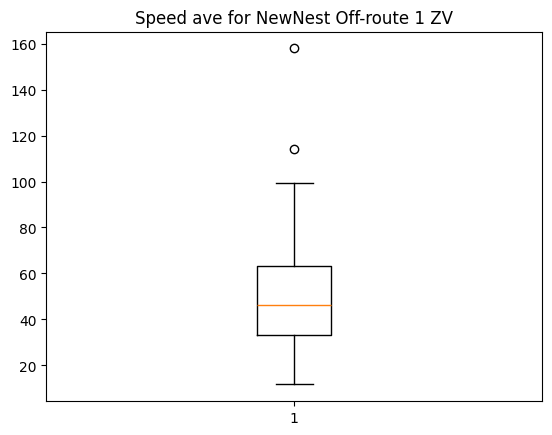

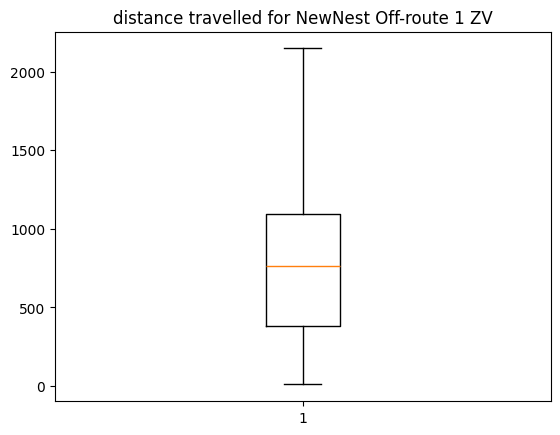

In [318]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Off-route 1 ZV', all=False)

In [319]:
np.mean(straightness)

0.4706994019413217

          Date   ID  frame           x           y     Nest      Condition  \
477768  Aug-21  552      0   28.158064    8.178162  NewNest  On-route 1 ZV   
477769  Aug-21  552      1   28.233856    8.230048  NewNest  On-route 1 ZV   
477770  Aug-21  552      2   28.415277    8.261939  NewNest  On-route 1 ZV   
477771  Aug-21  552      3   28.463771    8.260599  NewNest  On-route 1 ZV   
477772  Aug-21  552      4   28.527462    8.259917  NewNest  On-route 1 ZV   
...        ...  ...    ...         ...         ...      ...            ...   
480957  Aug-21  552   4544  183.654208  221.750631  NewNest  On-route 1 ZV   
480958  Aug-21  552   4545  184.455609  221.912415  NewNest  On-route 1 ZV   
480959  Aug-21  552   4546  184.696131  221.887814  NewNest  On-route 1 ZV   
480960  Aug-21  552   4547  185.061516  221.935726  NewNest  On-route 1 ZV   
480961  Aug-21  552   4548  185.211976  222.035313  NewNest  On-route 1 ZV   

        delta_distance(pix)  speed(px/s)    accumdist  
477768 

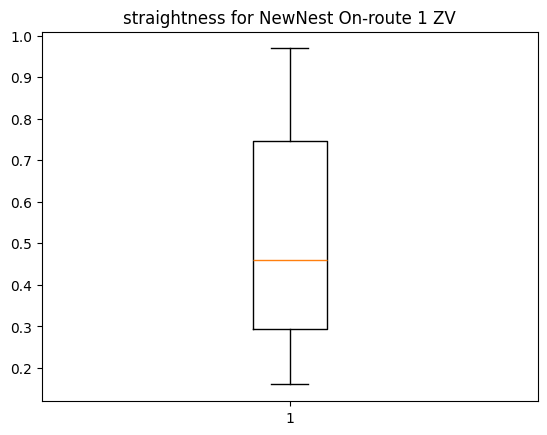

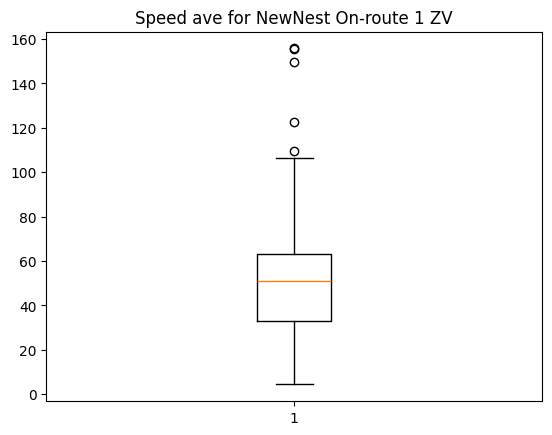

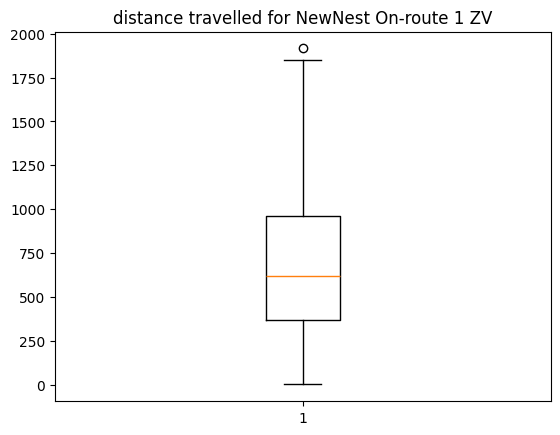

In [320]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='On-route 1 ZV', all=False)

In [321]:
np.mean(straightness)

0.515766259992854

           Date   ID  frame           x          y     Nest       Condition  \
1382807  Sep-09  882      0    3.936816 -12.505001  NewNest  On-route 1B ZV   
1382808  Sep-09  882      1    3.639135 -12.697918  NewNest  On-route 1B ZV   
1382809  Sep-09  882      2    3.770653 -12.882297  NewNest  On-route 1B ZV   
1382810  Sep-09  882      3    4.118472 -12.869364  NewNest  On-route 1B ZV   
1382811  Sep-09  882      4    5.786513 -13.185749  NewNest  On-route 1B ZV   
...         ...  ...    ...         ...        ...      ...             ...   
1384207  Sep-09  882   1402 -262.852319  65.678959  NewNest  On-route 1B ZV   
1384208  Sep-09  882   1403 -263.855950  65.014884  NewNest  On-route 1B ZV   
1384209  Sep-09  882   1404 -264.341273  64.238415  NewNest  On-route 1B ZV   
1384210  Sep-09  882   1405 -264.901219  63.733383  NewNest  On-route 1B ZV   
1384211  Sep-09  882   1406 -265.126628  63.508564  NewNest  On-route 1B ZV   

         delta_distance(pix)  speed(px/s)   accumdi

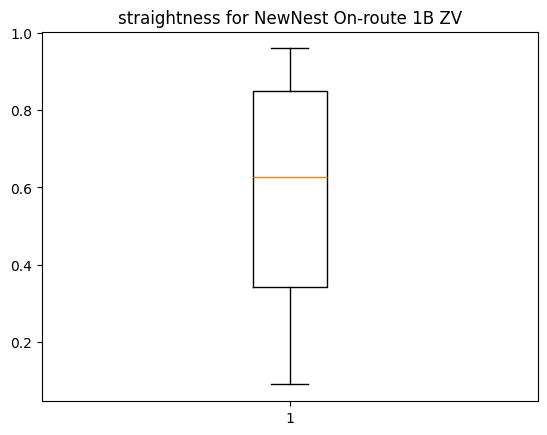

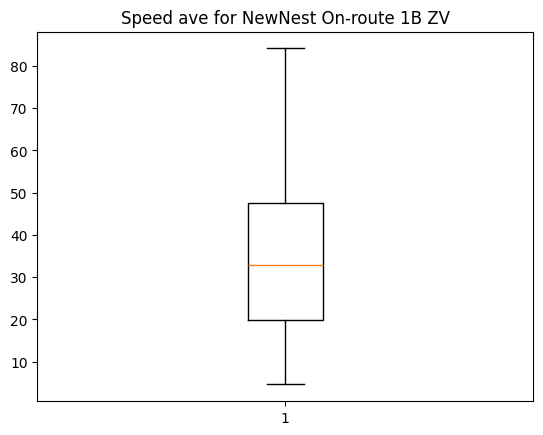

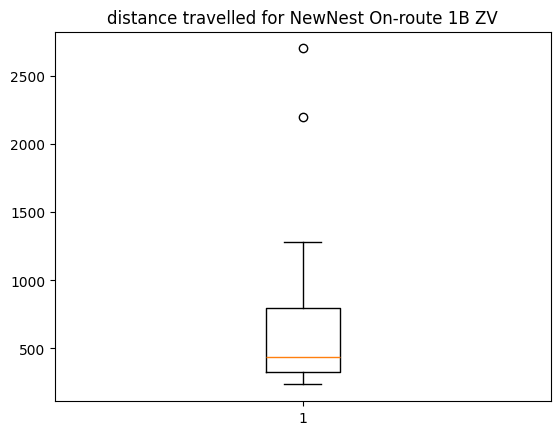

In [322]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='On-route 1B ZV', all=False)

In [323]:
np.mean(straightness)

0.5883135681989131

          Date   ID  frame           x           y     Nest      Condition  \
467579  Aug-21  567      0   16.320381   -0.318169  NewNest  On-route 2 ZV   
467580  Aug-21  567      1   16.410473   -0.345666  NewNest  On-route 2 ZV   
467581  Aug-21  567      2   16.244408   -0.429702  NewNest  On-route 2 ZV   
467582  Aug-21  567      3   16.334941   -0.331622  NewNest  On-route 2 ZV   
467583  Aug-21  567      4   16.317950   -0.320182  NewNest  On-route 2 ZV   
...        ...  ...    ...         ...         ...      ...            ...   
469658  Aug-21  567   2141  238.200535  180.492440  NewNest  On-route 2 ZV   
469659  Aug-21  567   2142  237.424433  181.003565  NewNest  On-route 2 ZV   
469660  Aug-21  567   2143  236.991708  181.044810  NewNest  On-route 2 ZV   
469661  Aug-21  567   2144  237.960371  180.566348  NewNest  On-route 2 ZV   
469662  Aug-21  567   2145  238.136157  180.508294  NewNest  On-route 2 ZV   

        delta_distance(pix)  speed(px/s)   accumdist  
467579  

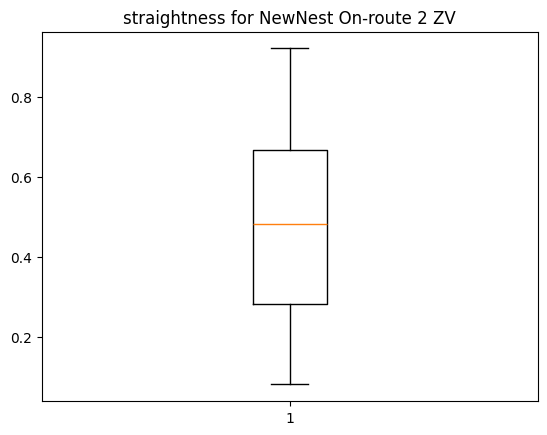

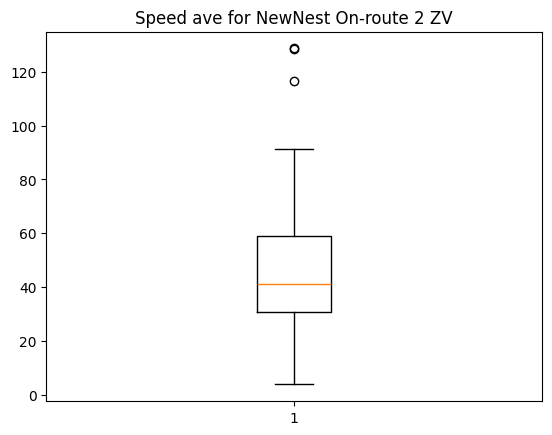

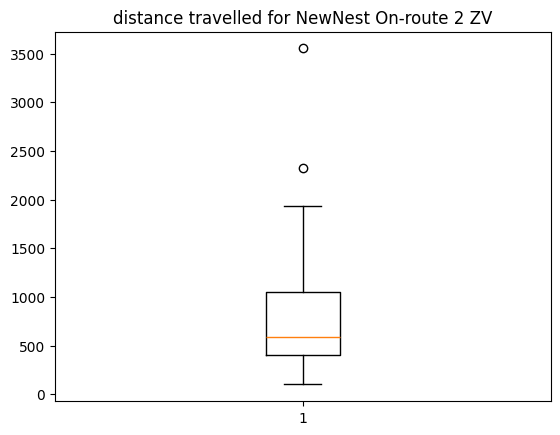

In [324]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='On-route 2 ZV', all=False)

In [325]:
np.mean(straightness)

0.4911545524505283

           Date   ID  frame           x          y     Nest      Condition  \
1081724  Aug-30  810      0  -36.561547   3.527568  NewNest  Unfamiliar FV   
1081725  Aug-30  810      1  -36.600119   3.481257  NewNest  Unfamiliar FV   
1081726  Aug-30  810      2  -36.587041   3.535041  NewNest  Unfamiliar FV   
1081727  Aug-30  810      3  -36.614477   3.527188  NewNest  Unfamiliar FV   
1081728  Aug-30  810      4  -36.606145   3.614147  NewNest  Unfamiliar FV   
...         ...  ...    ...         ...        ...      ...            ...   
1087998  Aug-30  810   6281 -264.793057 -20.311979  NewNest  Unfamiliar FV   
1087999  Aug-30  810   6282 -265.931881 -20.779361  NewNest  Unfamiliar FV   
1088000  Aug-30  810   6283 -267.231912 -21.207480  NewNest  Unfamiliar FV   
1088001  Aug-30  810   6284 -267.826077 -21.303136  NewNest  Unfamiliar FV   
1088002  Aug-30  810   6285 -268.886754 -20.695292  NewNest  Unfamiliar FV   

         delta_distance(pix)  speed(px/s)   accumdist  
1081724

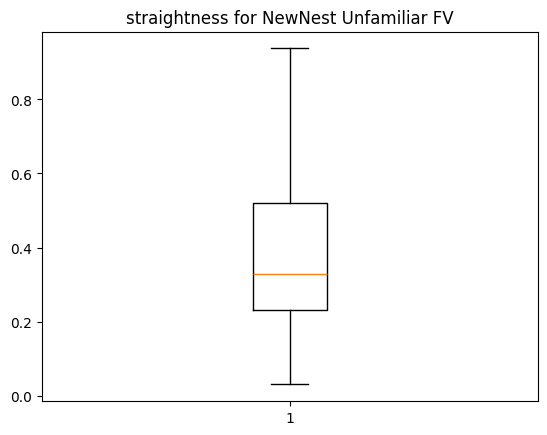

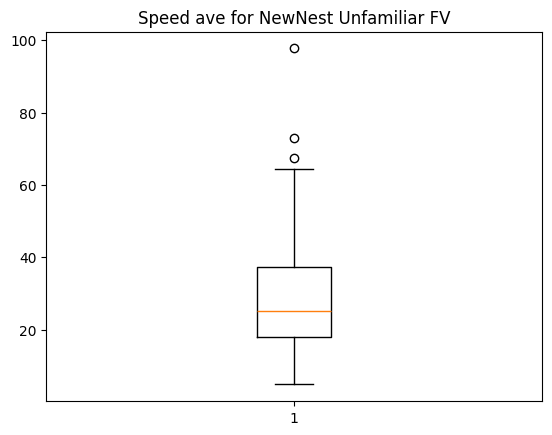

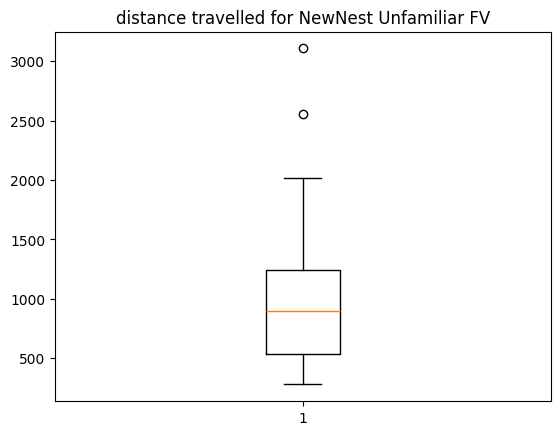

In [326]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Unfamiliar FV', all=False)

In [327]:
np.mean(straightness)

0.38764221224197787

          Date   ID  frame          x           y     Nest      Condition  \
651336  Aug-27  642      0   8.389464    8.207345  NewNest  Unfamiliar ZV   
651337  Aug-27  642      1   8.725609    8.482640  NewNest  Unfamiliar ZV   
651338  Aug-27  642      2   8.950722    8.901111  NewNest  Unfamiliar ZV   
651339  Aug-27  642      3   9.406584    9.125335  NewNest  Unfamiliar ZV   
651340  Aug-27  642      4   9.983262    9.495501  NewNest  Unfamiliar ZV   
...        ...  ...    ...        ...         ...      ...            ...   
654437  Aug-27  642   3117 -89.161267  257.600424  NewNest  Unfamiliar ZV   
654438  Aug-27  642   3118 -89.173288  257.560742  NewNest  Unfamiliar ZV   
654439  Aug-27  642   3119 -89.210781  257.593069  NewNest  Unfamiliar ZV   
654440  Aug-27  642   3120 -89.211298  257.558267  NewNest  Unfamiliar ZV   
654441  Aug-27  642   3121 -89.210153  257.570950  NewNest  Unfamiliar ZV   

        delta_distance(pix)  speed(px/s)   accumdist  
651336              

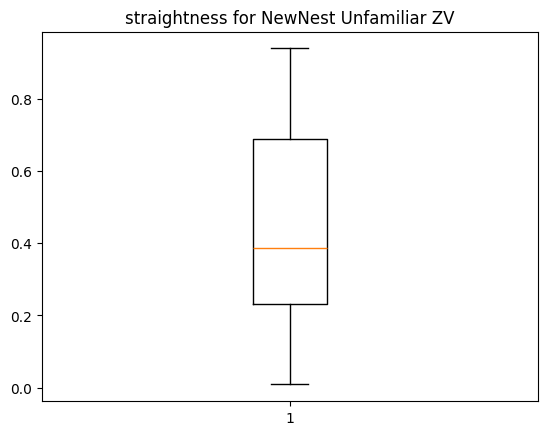

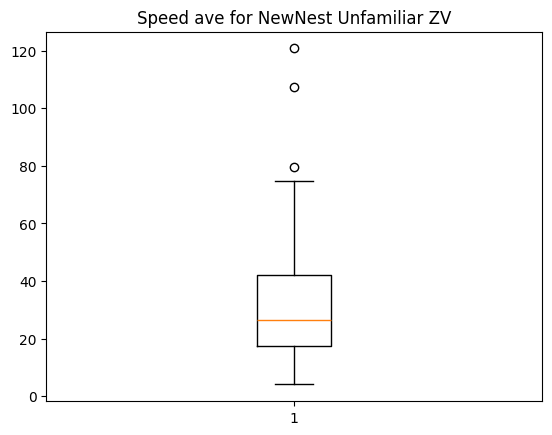

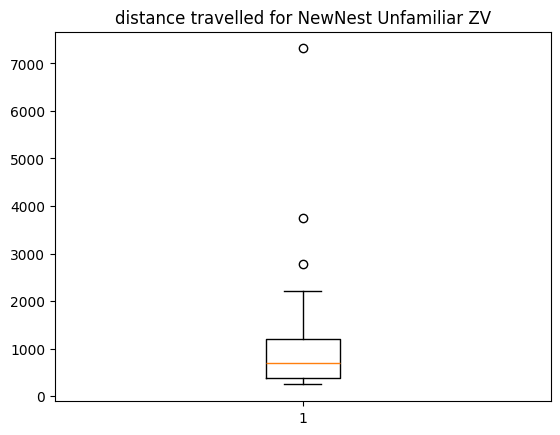

In [328]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Unfamiliar ZV', all=False)

In [329]:
np.mean(straightness)

0.4608956851033878

           Date   ID  frame           x           y     Nest        Condition  \
2066012  Sep-10  944      0  -39.323779  -25.839401  NewNest  Unfamiliar ZV 2   
2066013  Sep-10  944      1  -39.909704  -26.559958  NewNest  Unfamiliar ZV 2   
2066014  Sep-10  944      2  -40.568373  -26.827602  NewNest  Unfamiliar ZV 2   
2066015  Sep-10  944      3  -40.935015  -27.087818  NewNest  Unfamiliar ZV 2   
2066016  Sep-10  944      4  -41.627736  -27.769268  NewNest  Unfamiliar ZV 2   
...         ...  ...    ...         ...         ...      ...              ...   
2066385  Sep-10  944    373 -153.547955 -237.215135  NewNest  Unfamiliar ZV 2   
2066386  Sep-10  944    374 -153.691756 -237.665075  NewNest  Unfamiliar ZV 2   
2066387  Sep-10  944    375 -153.995691 -238.382625  NewNest  Unfamiliar ZV 2   
2066388  Sep-10  944    376 -154.115045 -238.591594  NewNest  Unfamiliar ZV 2   
2066389  Sep-10  944    377 -154.223267 -239.053148  NewNest  Unfamiliar ZV 2   

         delta_distance(pix

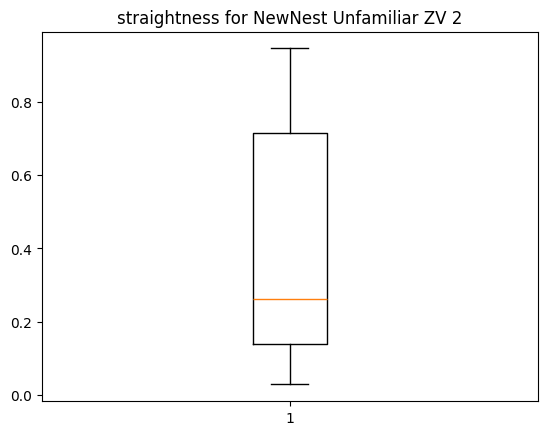

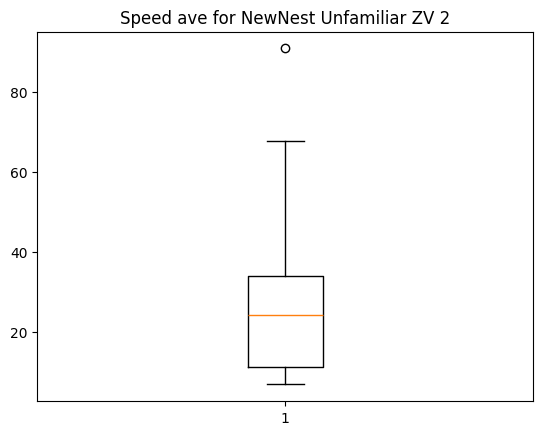

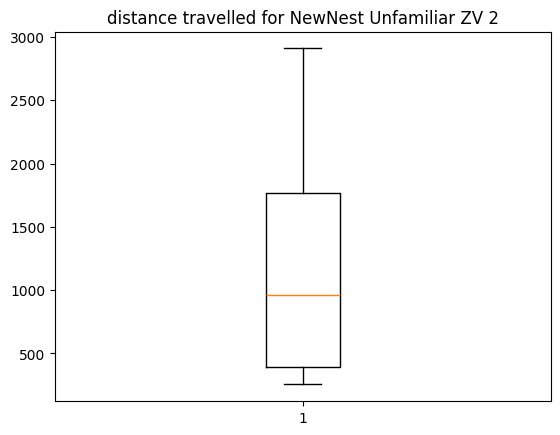

In [330]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Unfamiliar ZV 2', all=False)

In [331]:
np.mean(straightness)

0.38022948088198344

           Date   ID  frame           x           y     Nest        Condition  \
1770384  Sep-10  976      0   -2.893655   20.539493  NewNest  Unfamiliar ZV 3   
1770385  Sep-10  976      1   -2.953198   20.558375  NewNest  Unfamiliar ZV 3   
1770386  Sep-10  976      2   -2.995277   20.571919  NewNest  Unfamiliar ZV 3   
1770387  Sep-10  976      3   -2.997341   20.594041  NewNest  Unfamiliar ZV 3   
1770388  Sep-10  976      4   -2.995597   20.583120  NewNest  Unfamiliar ZV 3   
...         ...  ...    ...         ...         ...      ...              ...   
1800695  Sep-10  976  30354 -228.611596  169.581376  NewNest  Unfamiliar ZV 3   
1800696  Sep-10  976  30355 -228.611266  169.567975  NewNest  Unfamiliar ZV 3   
1800697  Sep-10  976  30356 -228.610772  169.545326  NewNest  Unfamiliar ZV 3   
1800698  Sep-10  976  30357 -228.611533  169.547763  NewNest  Unfamiliar ZV 3   
1800699  Sep-10  976  30358 -228.676134  169.650426  NewNest  Unfamiliar ZV 3   

         delta_distance(pix

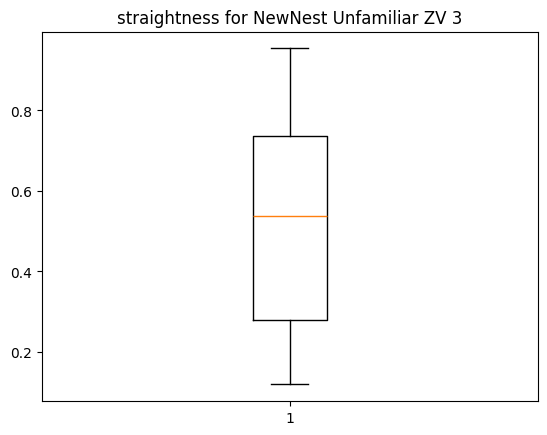

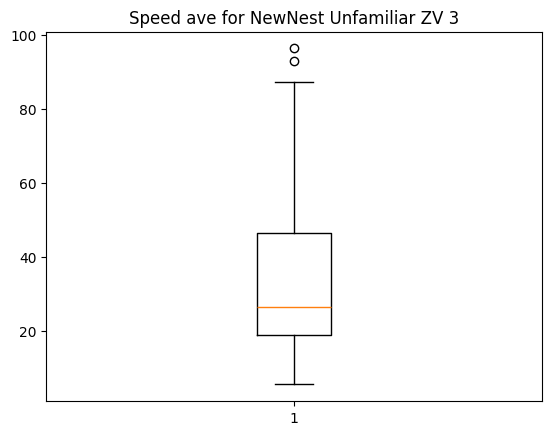

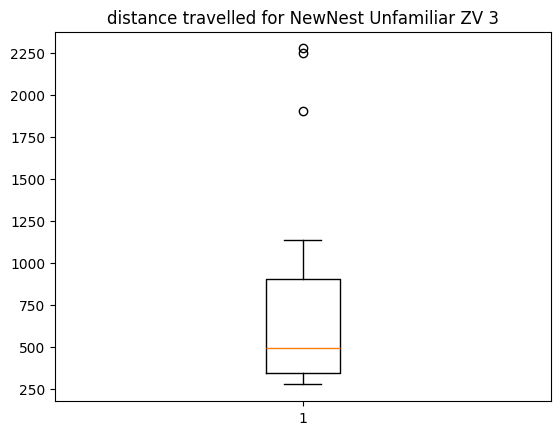

In [332]:
straightness = stats_condition(df=antTrackDF, nest='NewNest', condition='Unfamiliar ZV 3', all=False)

In [333]:
np.mean(straightness)

0.516279035183242

# this heading dir

In [197]:
def rayleigh_circmean(final_headings_list_theta):
    # Cornelia - calc circ mean if path is directed
    # rayleigh distribution - observed when overall magnitude is related to direction
    """ Takes in a list of theta heading directions in radians
        Outputs a circular mean IF rayleigh test score below 0.05"""
    rayleigh_ans = astro.rayleightest(np.array(final_headings_list_theta))
    print(f"rayleigh_ans :  {rayleigh_ans}")
    # calc the mean of all final heading directions    
    #print("rayleigh directedness res ", type(rayleigh_ans))
    if rayleigh_ans <= 0.05:
        circmean_heading_theta = get_circmean(final_headings_list_theta)
        #print(f"circ mean heading theta {circmean_heading_theta}")
    else:
        circmean_heading_theta = None
    return circmean_heading_theta

In [198]:
# functionalising and working out best offset


def heading_workingout(df, nest, condition, all=True, seyiornay=False, offset=(False, 180), arrows=-1, offsettype=1):
    # 240425 - using scipy circular stats functions
    # sample df by nest and condition type
    """ Produces polar plot of multiple ant paths per condition.
         Final Heading is highlighted in blue O and beige arrows
         Paths plotted in grey
         x num of triangles drawn to show strategic points such as nest direction
         """

    
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # 
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    
    # lists to hold final headings (radians or degrees)
    final_headings_list_theta = []    
    final_r_list_theta = []
    fin_cirmean_heading = []
    headingdir_indiv = []

    
    # 'setting' vars for plotting
    alphaval_path = 0.15
    alpha_finalp = 0.7
    arrow_frames = arrows
    # set fig size
    fig = plt.figure(figsize=(10, 10)) #10, 10
    ax = fig.add_subplot(321,projection='polar') 

    if offset[0]:
        offsetval = offset[1]
    else:
        offsetval = 0
    """ BEGIN """
    for id in unique_ids:
        # subset df further by trial/ ant ID
        usedf = newdf[newdf['ID'] == id].copy()
        _x = np.array(usedf['x']) # getting out our cartesian coordinates from the df
        _y =  np.array(usedf['y'])
        #final_xy.append((_x[-1], _y[-1]))
        usedf, r_full = delta_pos(usedf,_x,_y) # change in x, y pos added to df

        if seyiornay== True:
            theta_full = headingdir_seyi(usedf) # Seyi function
        else:
            theta_full, r_full = cart2pola(_x,_y) # Nay function
        theta_full = [0 if maths.isnan(i) else i for i in theta_full] # hide that nan
        
        headingdir_indiv.append(get_circmean(theta_full))


        
        # Cornelia - path cutting  between 2 and 29 cm
        x_cut, y_cut = cut_path(r_full, _x, _y)
        theta, r = cart2pola(x_cut, y_cut) # transform to pola coordinates

        finalpoint_theta = theta[-1] # taking the final point in RADIANS

        if offsettype == 1:
            headings_end = [a + offsetval for a in np.rad2deg(theta_full)]#[arrow_frames:]]# theta_full[arrow_frames:] + offsetval
        elif offsettype ==2:
            headings_end = [rel2Nest(a) for a in np.rad2deg(theta_full)]
        elif offsettype ==3:
            headings_end = [(offsetval -a) for a in np.rad2deg(theta_full)]
        elif offsettype ==4:
            headings_end = [(offsetval -a) %360 for a in np.rad2deg(theta_full)]        

        ax.quiver(theta_full[arrow_frames:],  # x
                  r_full[arrow_frames:],      # y
                  np.sin(np.deg2rad(headings_end[arrow_frames:][0])),    # U
                  np.cos(np.deg2rad(r_full[arrow_frames:])),  # V
                  usedf['frame'][arrow_frames:],   # C
                  ec='k', cmap="Pastel1")# headings_end[:] headings_end[:]
        ax.scatter(theta_full[:], r_full[:], c='dimgray', s=0.7, alpha=alphaval_path)
        
        # too messy with everything as arrows - have last 5 frames as arrows?

        final_headings_list_theta.append(finalpoint_theta) #finalpoint_theta Append to final headings list (once per ant) #finalpoint_degree2theta
        final_r_list_theta.append(r[-1] ) # append to final radius list)

    # For all ants in this condition
    circmean_heading_theta = rayleigh_circmean(final_headings_list_theta)
    if circmean_heading_theta is not None:
        fin_cirmean_heading.append(np.rad2deg(circmean_heading_theta))
    
    # taking the standard deviation of the final headings list
    mean_std_theta = scipy.stats.circstd(final_headings_list_theta)#np.std(final_headings_list_theta)
    print(f" circ mean std  theta {mean_std_theta}")

    # Blue O final heading direction
    scatter_theta = ax.scatter(final_headings_list_theta, final_r_list_theta, alpha=alpha_finalp, marker='$o$',s= 60) # plot the final heading directions
    ax.title.set_text(f'{nest}  {condition} offset{offset[0]} offsetype{offsettype}')
    
    add_plot_arrows(ax,(final_r_list_theta, 'blue', "fin theta"),(circmean_heading_theta, 'green', "CircMean"),(mean_std_theta, 'orange', "CircSTD"))

    ax.grid(False)
    plt.xticks([]) 
    plt.yticks([])
    plt.show()
    return headingdir_indiv, fin_cirmean_heading

        

 mean heading   : 4.209336315209403
 mean heading   : 1.907299872481373
 mean heading   : 1.692842935256547
 mean heading   : 2.131072668364288
 mean heading   : 5.414915902449275
 mean heading   : 2.2261079301341358
 mean heading   : 0.7015267628359986
 mean heading   : 3.2624236929182104
 mean heading   : 1.3630970980451829
 mean heading   : 3.9094592127826715
 mean heading   : 4.22340404414687
 mean heading   : 4.744081422113042
 mean heading   : 1.7295722358435137
 mean heading   : 5.461839398041534
 mean heading   : 3.860273674330784
 mean heading   : 3.0427053942329065
 mean heading   : 1.4804469063051706
 mean heading   : 2.148074592127303
 mean heading   : 0.5622456159577546
 mean heading   : 4.035483997697474
 mean heading   : 2.4122860588835255
 mean heading   : 4.889466689205704
 mean heading   : 0.1359720887018208
 mean heading   : 2.460499054639346
 mean heading   : 0.024199857765370484
 mean heading   : 0.9054382948059441
 mean heading   : 3.5038511795430973
 mean heading

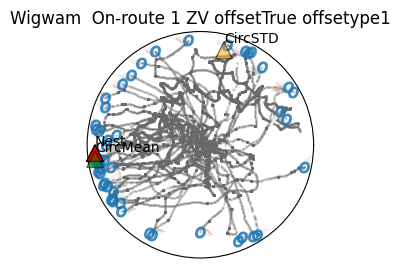

In [199]:
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'Wigwam', "On-route 1 ZV", offset=(True, 180), arrows=-7)

In [249]:
val = 0.00030034494856347866


print("{:.3e}".format(val))

3.003e-04


In [200]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 3.452556148192242
197.8168958233595


In [201]:
print(fin_cirmean_heading)

[183.31122577784743]


In [202]:
np.unique(antTrackDF['Condition'][(antTrackDF['Nest']=='Wigwam')])

array(['Off-route 1 ZV', 'On-route 1 ZV', 'On-route 2 ZV',
       'Unfamiliar FV', 'Unfamiliar ZV'], dtype=object)

 mean heading   : 5.692376061534227
 mean heading   : 3.221390576586453
 mean heading   : 2.256714408033279
 mean heading   : 4.861198296536555
 mean heading   : 3.1491506074589983
 mean heading   : 5.143563143924959
 mean heading   : 2.7857549381846862
 mean heading   : 1.6245171006868901
 mean heading   : 4.080951127321675
 mean heading   : 2.879870090270525
 mean heading   : 4.309067593111989
 mean heading   : 4.199256698895228
 mean heading   : 1.4754531850478632
 mean heading   : 0.6439238338051508
 mean heading   : 4.791321026234301
 mean heading   : 4.98502505557149
 mean heading   : 1.4090282957514544
 mean heading   : 3.4785205529678667
 mean heading   : 0.3599888840832725
 mean heading   : 3.711515774775326
 mean heading   : 5.850619586805491
 mean heading   : 2.080819703956404
 mean heading   : 2.8090560507157076
 mean heading   : 5.972361455816823
 mean heading   : 2.570646395857781
 mean heading   : 3.7162877206863465
 mean heading   : 1.3117828699248755
 mean heading   : 

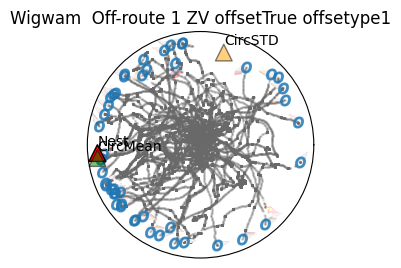

In [203]:
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'Wigwam', "Off-route 1 ZV", offset=(True, 180), arrows=-7)

In [250]:
val =0.00028775179695673427
print("{:.3e}".format(val))

2.878e-04


In [204]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 2.9309189582913726
167.92928640497541


In [205]:
print(fin_cirmean_heading)

[182.7577811340581]


 mean heading   : 0.15287969216211098
 mean heading   : 1.436682760024447
 mean heading   : 5.478256212618861
 mean heading   : 1.9373704999237369
 mean heading   : 4.025942127232565
 mean heading   : 4.512140682895845
 mean heading   : 2.5919023706188207
 mean heading   : 6.149113438183125
 mean heading   : 2.564036373773721
 mean heading   : 5.960563617302201
 mean heading   : 0.4137442419760125
 mean heading   : 1.6665866899702222
 mean heading   : 0.3401772305126702
 mean heading   : 1.219146338626992
 mean heading   : 1.3648062561808372
 mean heading   : 2.3691999982991083
 mean heading   : 1.585061594050265
 mean heading   : 0.5823972204572189
 mean heading   : 1.1617589251521248
 mean heading   : 0.29236246932691523
 mean heading   : 1.7322420532603193
 mean heading   : 3.7720761363720623
 mean heading   : 0.46845669323215766
 mean heading   : 2.285061214208068
 mean heading   : 0.7407258448485939
 mean heading   : 0.7874212589032709
 mean heading   : 2.609790146001901
 mean hea

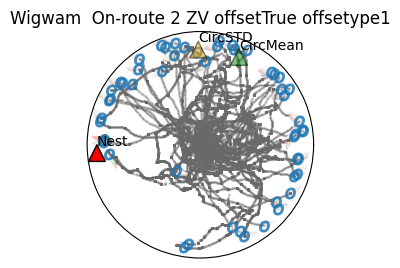

In [206]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'Wigwam', "On-route 2 ZV", offset=(True, 180), arrows=-7)

In [251]:
val = 0.017399572219046606
print("{:.3e}".format(val))

1.740e-02


In [207]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 0.8074341136840908
46.26256694898471


In [208]:
print(fin_cirmean_heading)

[68.17690948211602]


In [209]:
# "Unfamiliar FV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'Wigwam', "Unfamiliar FV", offset=(True, 180), arrows=-7)

 mean heading   : 3.7105392349978334
 mean heading   : 0.2949133352813312
 mean heading   : 2.6639114934039796
 mean heading   : 0.19637518750541505
 mean heading   : 3.159337574464043
 mean heading   : 0.7256054349764475
 mean heading   : 4.189598492623866
 mean heading   : 1.272993247245192
 mean heading   : 2.9874914364022116
 mean heading   : 3.3448114397808197
 mean heading   : 1.124024741650546
 mean heading   : 5.8536832005588755
 mean heading   : 1.5233817860802648
 mean heading   : 4.510820425204623
 mean heading   : 5.8927551994383505
 mean heading   : 0.00887021337610377
 mean heading   : 2.3832590324627714
 mean heading   : 0.4333822323922896
 mean heading   : 2.915140881007921
 mean heading   : 3.770783429019942
 mean heading   : 1.0410158415718445
 mean heading   : 4.239056130954246
 mean heading   : 3.890006132215726
 mean heading   : 0.22594424602764251
 mean heading   : 1.0111480534595618
 mean heading   : 1.5419966843607786
 mean heading   : 3.892976730142034
 mean he

TypeError: float() argument must be a string or a real number, not 'NoneType'

<Figure size 1000x1000 with 1 Axes>

In [210]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 1.6848225512097383
96.53322141278201


In [211]:
print(fin_cirmean_heading)

[]


 mean heading   : 1.2842467537260345
 mean heading   : 5.0002905956372965
 mean heading   : 4.508832071682443
 mean heading   : 2.31364688793301
 mean heading   : 0.9532009745750265
 mean heading   : 4.682116482019305
 mean heading   : 6.086008769133744
 mean heading   : 3.0675708780457898
 mean heading   : 5.1208089566677675
 mean heading   : 2.7219069681350314
 mean heading   : 2.561226240220693
 mean heading   : 1.8894277777854782
 mean heading   : 4.317985398008826
 mean heading   : 0.7081404023338547
 mean heading   : 0.9259000039346699
 mean heading   : 5.037412475307072
 mean heading   : 5.996003517744339
 mean heading   : 3.7980546902561936
 mean heading   : 3.192575777104361
 mean heading   : 3.764272506067369
 mean heading   : 1.8964188113146845
 mean heading   : 5.7792373414004645
 mean heading   : 4.118440048610029
 mean heading   : 0.1370533489853544
 mean heading   : 4.114111958103848
 mean heading   : 0.22889651522445384
 mean heading   : 2.3688733037206315
 mean heading

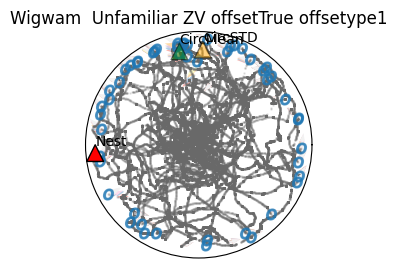

In [212]:
#"Unfamiliar ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'Wigwam', "Unfamiliar ZV", offset=(True, 180), arrows=-7)

In [252]:
val = 0.007473447023645169
print("{:.3e}".format(val))

7.473e-03


In [213]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 2.188315803464822
125.38125978031404


In [214]:
print(fin_cirmean_heading)

[100.7554000661974]


## NewNest

 mean heading   : 0.9569852012863627
 mean heading   : 2.3019071235694173
 mean heading   : 3.2962857067770357
 mean heading   : 5.4073895208784855
 mean heading   : 4.674686846836578
 mean heading   : 1.1789013567173678
 mean heading   : 4.238708012242699
 mean heading   : 2.6226979142990503
 mean heading   : 2.6730860217687207
 mean heading   : 2.300990188915435
 mean heading   : 0.5778470559279919
 mean heading   : 3.3610378120901285
 mean heading   : 5.263640257099685
 mean heading   : 4.295855904940169
 mean heading   : 5.9780575608346025
 mean heading   : 2.192999984082798
 mean heading   : 0.9092262099127951
 mean heading   : 2.0583022526452037
 mean heading   : 1.8160607038454906
 mean heading   : 4.880447609623036
 mean heading   : 5.257841169552197
 mean heading   : 0.18747867403672566
 mean heading   : 6.208738548823383
 mean heading   : 4.516871447212157
 mean heading   : 4.21930163337977
 mean heading   : 3.8736315446353453
 mean heading   : 1.2659201632837038
 mean headin

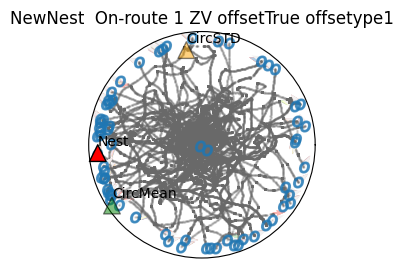

In [215]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "On-route 1 ZV", offset=(True, 180), arrows=-7)

In [253]:
val = 0.031155860159884606
print("{:.3e}".format(val))

3.116e-02


In [216]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 2.942334328182754
168.58333892133228


In [217]:
print(fin_cirmean_heading)

[210.24095109545107]


 mean heading   : 2.4467098586499083
 mean heading   : 1.3858560511466158
 mean heading   : 2.9200605738575183
 mean heading   : 0.9016217721959497
 mean heading   : 4.110635541837637
 mean heading   : 4.945603212975522
 mean heading   : 5.012345051076897
 mean heading   : 1.8802402701633778
 mean heading   : 0.0786018513359919
 mean heading   : 2.2695725964136853
 mean heading   : 4.368004387198679
 mean heading   : 4.358910138977365
 mean heading   : 0.3068162155091842
 mean heading   : 5.233095165688912
 mean heading   : 1.6931169157191692
 mean heading   : 3.5025108387357307
 mean heading   : 2.684770005819726
 mean heading   : 2.178516246234565
 mean heading   : 4.379466422237228
 mean heading   : 1.8029155989419872
 mean heading   : 5.366981975726464
 mean heading   : 2.2136651457765946
 mean heading   : 2.5576869608492743
 mean heading   : 2.346292858679421
 mean heading   : 3.103241150303843
 mean heading   : 5.212920307239463
 mean heading   : 2.7613592255200885
 mean heading 

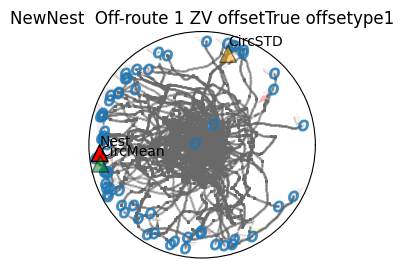

In [218]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Off-route 1 ZV", offset=(True, 180), arrows=-7)

In [254]:
val =1.3741434829725455e-05
print("{:.3e}".format(val))

1.374e-05


In [219]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 3.2053165089441484
183.65110796610668


In [220]:
print(fin_cirmean_heading)

[185.96410548487782]


In [221]:
np.unique(antTrackDF['Condition'][(antTrackDF['Nest']=='NewNest')])

array(['Eye-capped off-route 1', 'Eye-capped on-route 1', 'Minus 3m ZV',
       'Off-route 1 ZV', 'On-route 1 ZV', 'On-route 1B ZV',
       'On-route 2 ZV', 'Plus 3m ZV', 'Route 0m ZV', 'Unfamiliar FV',
       'Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3'],
      dtype=object)

 mean heading   : 3.9312671786595206
 mean heading   : 5.109220885535247
 mean heading   : 4.728241256558225
 mean heading   : 2.2965466633312968
 mean heading   : 0.784257926431179
 mean heading   : 4.935202644942148
 mean heading   : 4.758505024458699
 mean heading   : 2.290934624502038
 mean heading   : 3.299139036265829
 mean heading   : 2.0194306498701255
 mean heading   : 2.4859222523202864
 mean heading   : 2.840941875249387
 mean heading   : 5.80058544461078
 mean heading   : 1.041373351195939
 mean heading   : 2.2864656039133155
 mean heading   : 2.7719440503096906
 mean heading   : 4.233173688466247
 mean heading   : 1.956455354152276
 mean heading   : 1.8281987591375473
 mean heading   : 1.2645957209738403
 mean heading   : 1.0314508141924184
 mean heading   : 2.4592543896163517
 mean heading   : 2.832100941767551
 mean heading   : 1.7614199239715729
 mean heading   : 2.4681422885741306
 mean heading   : 3.8988338159048874
 mean heading   : 4.011984831003837
 mean heading   

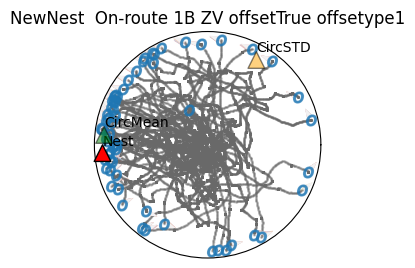

In [222]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "On-route 1B ZV", offset=(True, 180), arrows=-7)

In [255]:
val = 5.798771728086173e-09
print("{:.3e}".format(val))

5.799e-09


In [223]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 3.177574843053891
182.0616275939329


In [224]:
print(fin_cirmean_heading)

[170.0665440972713]


In [225]:
#
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "On-route 2 ZV", offset=(True, 180), arrows=-7)

 mean heading   : 6.162326396041661
 mean heading   : 3.534827986663419
 mean heading   : 5.443252394782235
 mean heading   : 5.063820657405948
 mean heading   : 0.3934546001085066
 mean heading   : 4.3062502225193935
 mean heading   : 2.4974499706362785
 mean heading   : 2.8811500902299585
 mean heading   : 5.955587533618849
 mean heading   : 0.38606465102241716
 mean heading   : 5.966732714069539
 mean heading   : 1.0178866603283923
 mean heading   : 5.449276445261857
 mean heading   : 0.1567371705928705
 mean heading   : 2.406026193112346
 mean heading   : 5.319615376931168
 mean heading   : 5.465617096087139
 mean heading   : 5.473093166084496
 mean heading   : 1.4032545846381954
 mean heading   : 2.008114314391837
 mean heading   : 2.8677842971658682
 mean heading   : 0.9331379190638174
 mean heading   : 4.631950370812068
 mean heading   : 0.8186767924110914
 mean heading   : 3.6327616620359757
 mean heading   : 5.663465572320274
 mean heading   : 6.076253747317022
 mean heading  

TypeError: float() argument must be a string or a real number, not 'NoneType'

<Figure size 1000x1000 with 1 Axes>

In [226]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 0.35996538847870757
20.624497530617052


In [227]:
print(fin_cirmean_heading)

[]


 mean heading   : 1.732261143642354
 mean heading   : 2.709057937829098
 mean heading   : 5.348921637926383
 mean heading   : 3.661131636334512
 mean heading   : 3.466698658641749
 mean heading   : 4.244179023698801
 mean heading   : 5.603089223537545
 mean heading   : 0.7207545092936063
 mean heading   : 3.678385050188019
 mean heading   : 2.4929793177785333
 mean heading   : 4.821002855519284
 mean heading   : 1.2391992811625507
 mean heading   : 5.745007309039275
 mean heading   : 2.982009833482495
 mean heading   : 5.1008679433974695
 mean heading   : 6.221580682387224
 mean heading   : 5.03024908980586
 mean heading   : 3.9306002646178815
 mean heading   : 2.8669542752639514
 mean heading   : 5.510381172370433
 mean heading   : 5.076502684269132
 mean heading   : 6.005049021294015
 mean heading   : 4.907660692151013
 mean heading   : 2.3928292586803552
 mean heading   : 4.953864603257934
 mean heading   : 1.7672414776045948
 mean heading   : 1.2626826361089991
 mean heading   : 5.

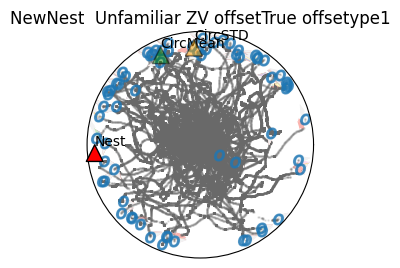

In [228]:

headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Unfamiliar ZV", offset=(True, 180), arrows=-7)

In [256]:
val = 0.0091137526047724
print("{:.3e}".format(val))

9.114e-03


In [229]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 2.438220035006478
139.69971753011103


In [230]:
print(fin_cirmean_heading)

[112.02923466301259]


In [231]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Unfamiliar FV", offset=(True, 180), arrows=-7)

 mean heading   : 3.0057895657138975
 mean heading   : 2.640172989674324
 mean heading   : 0.9824907002234841
 mean heading   : 5.244812930335206
 mean heading   : 3.805262106047201
 mean heading   : 2.2017420418125297
 mean heading   : 1.2183226535747644
 mean heading   : 3.562169950026598
 mean heading   : 0.24796804462031777
 mean heading   : 5.9504440890651
 mean heading   : 5.06085994025966
 mean heading   : 0.12691711103933828
 mean heading   : 2.9931475873423308
 mean heading   : 1.9878404850021956
 mean heading   : 2.778570000504079
 mean heading   : 3.5493116821261004
 mean heading   : 2.0901539772986393
 mean heading   : 5.186642235766556
 mean heading   : 4.553514729776511
 mean heading   : 0.42479542084891714
 mean heading   : 6.038602968843701
 mean heading   : 0.37899806067311603
 mean heading   : 4.038648523423083
 mean heading   : 4.2031502098467985
 mean heading   : 0.7122072932094252
 mean heading   : 4.842861247516439
 mean heading   : 0.6654614483638099
 mean headin

TypeError: float() argument must be a string or a real number, not 'NoneType'

<Figure size 1000x1000 with 1 Axes>

In [ ]:
val = 
print("{:.3e}".format(val))

In [232]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 3.0065668405993065
172.26359079032238


In [233]:
print(fin_cirmean_heading)

[]


In [234]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Unfamiliar ZV 2", offset=(True, 180), arrows=-7)

 mean heading   : 4.046710795692608
 mean heading   : 5.020499638934198
 mean heading   : 5.39586389704531
 mean heading   : 3.1601308144271627
 mean heading   : 3.253078108368009
 mean heading   : 2.181719399369352
 mean heading   : 5.4583990562071465
 mean heading   : 0.15563945944671773
 mean heading   : 3.8141185320119813
 mean heading   : 1.1649689620592953
 mean heading   : 3.274737284288054
 mean heading   : 0.18788559047994366
 mean heading   : 2.522482506667136
 mean heading   : 4.4693235486594025
 mean heading   : 1.7247200845234505
 mean heading   : 6.015676282111033
 mean heading   : 6.20844117948023
 mean heading   : 4.879521793881263
 mean heading   : 3.6049362843039314
 mean heading   : 4.654554155435607
 mean heading   : 2.004991601238446
 mean heading   : 3.9022141732054694
 mean heading   : 2.92296093741561
 mean heading   : 0.35796745714928896
 mean heading   : 0.3889916727288889
 mean heading   : 5.691932550102999
 mean heading   : 3.545157512519662
 mean heading   

TypeError: float() argument must be a string or a real number, not 'NoneType'

<Figure size 1000x1000 with 1 Axes>

In [235]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 4.830823244919291
276.78578350756857


In [236]:
print(fin_cirmean_heading)

[]


In [237]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Unfamiliar ZV 3", offset=(True, 180), arrows=-7)

 mean heading   : 1.9144627779923946
 mean heading   : 4.267163213708114
 mean heading   : 5.6849382273391855
 mean heading   : 4.6487867910880585
 mean heading   : 1.0608445597270837
 mean heading   : 3.2169697012968452
 mean heading   : 4.470098217820855
 mean heading   : 0.7159628889391364
 mean heading   : 1.2897966381212647
 mean heading   : 3.440656811468628
 mean heading   : 2.7408175515240476
 mean heading   : 5.390477330467108
 mean heading   : 5.833287074030086
 mean heading   : 3.715852492422327
 mean heading   : 3.42876615598009
 mean heading   : 1.4607922109532465
 mean heading   : 2.649855083020789
 mean heading   : 4.477671328342686
 mean heading   : 0.44606991306371274
 mean heading   : 4.399513202126797
 mean heading   : 2.0231524786558186
 mean heading   : 5.156743761410109
 mean heading   : 2.0039996245319447
 mean heading   : 6.170999511233317
rayleigh_ans :  0.32005239494858106
 circ mean std  theta 1.7431486412846722


TypeError: float() argument must be a string or a real number, not 'NoneType'

<Figure size 1000x1000 with 1 Axes>

In [238]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 3.7748929150258634
216.2854321448185


In [239]:
print(fin_cirmean_heading)

[]


 mean heading   : 6.192994633345246
 mean heading   : 3.6658195764835235
 mean heading   : 2.858748099506937
 mean heading   : 4.192021593093115
 mean heading   : 1.2168175118790614
 mean heading   : 2.4677716086490076
 mean heading   : 1.4265590944068272
 mean heading   : 0.057420708848473945
 mean heading   : 3.1199251607501015
 mean heading   : 3.2183926364590394
 mean heading   : 0.04599452924680446
 mean heading   : 5.036119145674228
 mean heading   : 2.7931796533212174
 mean heading   : 3.5344350270005576
 mean heading   : 3.566958354748352
 mean heading   : 1.1713021362900446
 mean heading   : 3.909673657345196
 mean heading   : 3.4885347873988874
 mean heading   : 0.4326219340037942
 mean heading   : 1.2310702970175675
 mean heading   : 2.6834461220878665
 mean heading   : 0.11383015330035377
 mean heading   : 3.8042874739826975
 mean heading   : 0.5479359078591556
 mean heading   : 4.055559203242766
 mean heading   : 5.143468936889099
 mean heading   : 0.641090034638595
 mean 

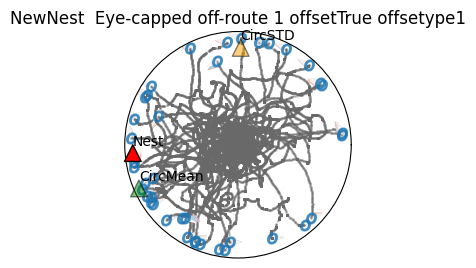

In [240]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Eye-capped off-route 1", offset=(True, 180), arrows=-7)

In [257]:
val = 0.024331492506389555
print("{:.3e}".format(val))

2.433e-02


In [241]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 3.417974009455392
195.8354852272021


In [242]:
print(fin_cirmean_heading)

[199.63314451117546]


 mean heading   : 2.952768689925833
 mean heading   : 1.4625755041158366
 mean heading   : 2.229034996802639
 mean heading   : 3.5240139057516022
 mean heading   : 0.552741612111466
 mean heading   : 5.9268739537648845
 mean heading   : 3.3333742436312823
 mean heading   : 5.301301377835193
 mean heading   : 3.920860659260758
 mean heading   : 1.5839212315702882
 mean heading   : 0.6648471150813035
 mean heading   : 3.4492705698171022
 mean heading   : 1.2886323778181838
 mean heading   : 3.6244506627250663
 mean heading   : 1.2652291801224789
 mean heading   : 1.130517605395565
 mean heading   : 0.8656608627025388
 mean heading   : 1.4357606804502345
 mean heading   : 1.5144676570754119
 mean heading   : 0.622645045371187
 mean heading   : 1.8053606135496538
 mean heading   : 0.035650017780064124
rayleigh_ans :  0.026414256224874404
 mean heading   : 1.471341864341913
 circ mean std  theta 1.3489992551638565


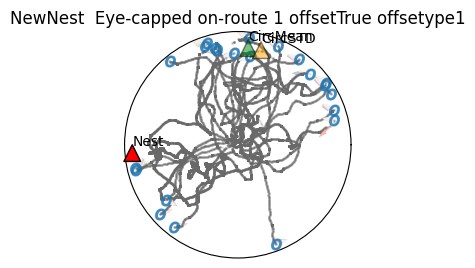

In [243]:
# "On-route 2 ZV")
headingdir_indiv, fin_cirmean_heading = heading_workingout(antTrackDF, 'NewNest', "Eye-capped on-route 1", offset=(True, 180), arrows=-7)

In [258]:
val = 0.026414256224874404
print("{:.3e}".format(val))

2.641e-02


In [244]:
print(np.rad2deg(get_circmean(headingdir_indiv)))

 mean heading   : 1.497011612469381
85.7724472765695


In [245]:
print(fin_cirmean_heading)

[84.30167904770173]
